In [2]:
import requests, pandas as pd

url_weather = "https://power.larc.nasa.gov/api/temporal/daily/point"
params_weather = {
    "start": "20140101",
    "end": "20251231",
    "latitude": 36.77,
    "longitude": -119.41,
    "parameters": "T2M_MAX,T2M_MIN,RH2M,PRECTOT,EVPTRNS",
    "community": "AG",
    "format": "JSON"
}

r1 = requests.get(url_weather, params=params_weather)
data_weather = r1.json()

df_weather = pd.DataFrame.from_dict(data_weather["properties"]["parameter"])
df_weather["date"] = pd.to_datetime(df_weather.index)
df_weather.reset_index(drop=True, inplace=True)
print(df_weather.head())


   EVPTRNS   RH2M  T2M_MIN  T2M_MAX  PRECTOTCORR       date
0      0.0  33.09     5.80    19.54          0.0 2014-01-01
1      0.0  34.60     8.39    19.92          0.0 2014-01-02
2      0.0  35.66     7.50    19.55          0.0 2014-01-03
3      0.0  34.02     6.59    19.05          0.0 2014-01-04
4      0.0  26.37     4.86    19.00          0.0 2014-01-05


In [ ]:
df_weather.shape

(4383, 6)

In [ ]:
import pandas as pd
import requests
from datetime import datetime, timedelta

def fetch_weatherbit_monthly(lat, lon, start_year, end_year, api_key):
    base_url = "https://api.weatherbit.io/v2.0/history/agweather"
    all_data = []

    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            start_date = datetime(year, month, 1)
            # compute end of month
            end_date = (start_date + pd.offsets.MonthEnd(1)).date()

            params = {
                "lat": lat,
                "lon": lon,
                "start_date": start_date.strftime("%Y-%m-%d"),
                "end_date": end_date.strftime("%Y-%m-%d"),
                "key": api_key
            }

            try:
                r = requests.get(base_url, params=params, timeout=30)
                data = r.json()

                if "data" in data:
                    df = pd.DataFrame(data["data"])
                    all_data.append(df)
                    print(f"Retrieved {len(df)} rows for {year}-{month:02d}")
                else:
                    print(f"No data for {year}-{month:02d}")
            except Exception as e:
                print(f"Error for {year}-{month:02d}: {e}")

    # combine all months
    if all_data:
        df_all = pd.concat(all_data, ignore_index=True)
        df_all["valid_date"] = pd.to_datetime(df_all["valid_date"])
        return df_all
    else:
        return pd.DataFrame()

In [ ]:
lat, lon = 36.77, -119.41  # example
api_key = "9eaaffa4443d439981624e100686f7b5"

df_soil = fetch_weatherbit_monthly(lat, lon, 2018, 2025, api_key)
print(df_soil.shape)
df_soil.head()


No data for 2018-01
No data for 2018-02
No data for 2018-03
No data for 2018-04
No data for 2018-05
No data for 2018-06
No data for 2018-07
No data for 2018-08
No data for 2018-09
No data for 2018-10
No data for 2018-11
No data for 2018-12
No data for 2019-01
No data for 2019-02
No data for 2019-03
No data for 2019-04
No data for 2019-05
No data for 2019-06
No data for 2019-07
No data for 2019-08
No data for 2019-09
No data for 2019-10
No data for 2019-11
No data for 2019-12
No data for 2020-01
No data for 2020-02
No data for 2020-03
No data for 2020-04
No data for 2020-05
No data for 2020-06
No data for 2020-07
No data for 2020-08
No data for 2020-09
No data for 2020-10
No data for 2020-11
No data for 2020-12
No data for 2021-01
No data for 2021-02
No data for 2021-03
No data for 2021-04
No data for 2021-05
No data for 2021-06
No data for 2021-07
No data for 2021-08
No data for 2021-09
No data for 2021-10
No data for 2021-11
No data for 2021-12
No data for 2022-01
No data for 2022-02


""


In [ ]:
# import requests
# import time

# url = "https://api.weatherbit.io/v2.0/history/agweather"

# params = {
#     "lat": 36.77,
#     "lon": -119.41,
#     "start_date": "2020-01-01",
#     "end_date": "2020-01-31",
#     "key": "5a7527f477b949b4a9b730193ff3e966"
# }

# r = requests.get("https://api.weatherbit.io/v2.0/history/agweather", params=params, timeout=30)
# time.sleep(1.2)

# print("Status Code:", r.status_code)
# print("Raw Response:", r.text[:500])

Status Code: 200
Raw Response: {"data":[{"bulk_soil_density":1520,"dlwrf_avg":17.08,"dlwrf_max":70,"dlwrf_net":17.08,"dswrf_avg":113.75,"dswrf_max":465,"dswrf_net":-113.75,"evapotranspiration":1.52,"precip":0,"pres_avg":999.8,"revision_status":"final","revision_version":"2.1","skin_temp_avg":6.7,"skin_temp_max":14.8,"skin_temp_min":2.6,"soilm_0_10cm":33.38,"soilm_100_200cm":262.75,"soilm_10_40cm":100.66,"soilm_40_100cm":149.56,"soilt_0_10cm":8,"soilt_100_200cm":16.3,"soilt_10_40cm":7.7,"soilt_40_100cm":10.4,"specific_humidity


In [ ]:
# url = "https://api.weatherbit.io/v2.0/current"
# params = {
#     "lat": 36.77,
#     "lon": -119.41,
#     "key": "5a7527f477b949b4a9b730193ff3e966"
# }

# r = requests.get(url, params=params)
# print(r.status_code)
# print(r.text)

200
{"count":1,"data":[{"app_temp":11.4,"aqi":22,"city_name":"Gravesboro","clouds":0,"country_code":"US","datetime":"2026-04-02:14","dewpt":9.5,"dhi":66,"dni":586,"elev_angle":14.69,"ghi":207,"gust":1.5,"h_angle":-75,"lat":36.77,"lon":-119.41,"ob_time":"2026-04-02 14:40","pod":"d","precip":0,"pres":994.2,"rh":87,"slp":1016,"snow":0,"solar_rad":207,"sources":["650SE","radar","satellite"],"state_code":"CA","station":"650SE","sunrise":"13:41","sunset":"02:21","temp":11.4,"timezone":"America/Los_Angeles","ts":1775140800,"uv":2,"vis":12.9,"weather":{"icon":"c01d","code":800,"description":"Clear sky"},"wind_cdir":"S","wind_cdir_full":"south","wind_dir":190,"wind_spd":1}]}



In [ ]:
df_soil.shape

NameError: name 'df_soil' is not defined

In [ ]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4383 entries, 0 to 4382
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   EVPTRNS      4383 non-null   float64       
 1   RH2M         4383 non-null   float64       
 2   T2M_MIN      4383 non-null   float64       
 3   T2M_MAX      4383 non-null   float64       
 4   PRECTOTCORR  4383 non-null   float64       
 5   date         4383 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(5)
memory usage: 205.6 KB


In [ ]:
df_weather.describe()

,EVPTRNS,RH2M,T2M_MIN,T2M_MAX,PRECTOTCORR,date
count,4383.000000,4383.000000,4383.000000,4383.000000,4383.000000,4383
mean,0.549596,47.250666,9.310917,22.197782,1.510281,2020-01-01 00:00:00.000000256
min,0.000000,8.070000,-10.630000,-0.300000,0.000000,2014-01-01 00:00:00
25%,0.000000,28.570000,3.655000,15.060000,0.000000,2016-12-31 12:00:00
50%,0.060000,44.970000,8.490000,21.930000,0.000000,2020-01-01 00:00:00
75%,0.500000,63.475000,15.540000,30.270000,0.090000,2022-12-31 12:00:00
max,7.620000,100.000000,26.360000,42.260000,89.310000,2025-12-31 00:00:00
std,1.087574,21.883553,7.225119,9.238221,5.856734,NaN


In [ ]:
df_weather.shape

(4383, 6)

In [ ]:
df_weather.isnull().sum()

,0
EVPTRNS,0
RH2M,0
T2M_MIN,0
T2M_MAX,0
PRECTOTCORR,0
date,0


In [ ]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4383 entries, 0 to 4382
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   EVPTRNS      4383 non-null   float64       
 1   RH2M         4383 non-null   float64       
 2   T2M_MIN      4383 non-null   float64       
 3   T2M_MAX      4383 non-null   float64       
 4   PRECTOTCORR  4383 non-null   float64       
 5   date         4383 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(5)
memory usage: 205.6 KB


In [ ]:
df_weather.shape

(4383, 6)

In [ ]:
import pandas as pd

df_weather['date'] = pd.to_datetime(df_weather['date'])
df_soil['valid_date'] = pd.to_datetime(df_soil['valid_date'])

df_merged = pd.merge(df_weather, df_soil, left_on='date', right_on='valid_date', how='inner')
df_merged.drop(columns=['valid_date'], inplace=True)

df_merged = df_merged.fillna(method='ffill')

print(df_merged.head())
print("Merged shape:", df_merged.shape)
df_merged.to_csv("merged_smart_water.csv", index=False)


   EVPTRNS   RH2M  T2M_MIN  T2M_MAX  PRECTOTCORR       date  \
0     0.48  65.03     3.05    13.60         0.10 2020-01-01   
1     0.64  63.18     2.89    15.37         0.03 2020-01-02   
2     0.70  51.74     4.78    17.73         0.00 2020-01-03   
3     0.53  48.59     3.98    14.17         0.00 2020-01-04   
4     0.48  51.75     2.61    11.72         0.00 2020-01-05   

   bulk_soil_density  dlwrf_avg  dlwrf_max  dlwrf_net  ...  soilt_40_100cm  \
0               1520      17.08         70      17.08  ...            10.4   
1               1520      13.33         50      13.33  ...            10.4   
2               1520      19.17         75      19.17  ...            10.4   
3               1520      19.58         80      19.58  ...            10.4   
4               1520      17.92         70      17.92  ...            10.4   

   specific_humidity  temp_2m_avg      timestamp_local        timestamp_utc  \
0            0.00537          9.4  2020-01-01T00:00:00  2020-01-01T00:00:

/tmp/ipykernel_6650/1612451813.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_merged = df_merged.fillna(method='ffill')


In [114]:
df_merged = pd.read_csv("/content/merged_smart_water (1).csv")

In [115]:
df_merged.head()

,EVPTRNS,RH2M,T2M_MIN,T2M_MAX,PRECTOTCORR,date,bulk_soil_density,dlwrf_avg,dlwrf_max,dlwrf_net,...,soilt_40_100cm,specific_humidity,temp_2m_avg,timestamp_local,timestamp_utc,v_soilm_0_10cm,v_soilm_100_200cm,v_soilm_10_40cm,v_soilm_40_100cm,wind_10m_spd_avg
0,0.48,65.03,3.05,13.60,0.10,2020-01-01,1520,17.08,70,17.08,...,10.4,0.00537,9.4,2020-01-01T00:00:00,2020-01-01T00:00:00,0.334,0.263,0.335,0.249,1.3
1,0.64,63.18,2.89,15.37,0.03,2020-01-02,1520,13.33,50,13.33,...,10.4,0.00600,8.4,2020-01-02T00:00:00,2020-01-02T00:00:00,0.329,0.263,0.331,0.249,1.0
2,0.70,51.74,4.78,17.73,0.00,2020-01-03,1520,19.17,75,19.17,...,10.4,0.00543,10.0,2020-01-03T00:00:00,2020-01-03T00:00:00,0.326,0.263,0.327,0.249,0.8
3,0.53,48.59,3.98,14.17,0.00,2020-01-04,1520,19.58,80,19.58,...,10.4,0.00539,10.8,2020-01-04T00:00:00,2020-01-04T00:00:00,0.318,0.263,0.320,0.247,1.7
4,0.48,51.75,2.61,11.72,0.00,2020-01-05,1520,17.92,70,17.92,...,10.4,0.00544,9.2,2020-01-05T00:00:00,2020-01-05T00:00:00,0.310,0.263,0.315,0.245,2.1


In [116]:
df_merged.shape

(2031, 38)

In [117]:
df_merged['date'] = pd.to_datetime(df_merged['date'])


In [118]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2031 entries, 0 to 2030
Data columns (total 38 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   EVPTRNS             2031 non-null   float64       
 1   RH2M                2031 non-null   float64       
 2   T2M_MIN             2031 non-null   float64       
 3   T2M_MAX             2031 non-null   float64       
 4   PRECTOTCORR         2031 non-null   float64       
 5   date                2031 non-null   datetime64[ns]
 6   bulk_soil_density   2031 non-null   int64         
 7   dlwrf_avg           2031 non-null   float64       
 8   dlwrf_max           2031 non-null   int64         
 9   dlwrf_net           2031 non-null   float64       
 10  dswrf_avg           2031 non-null   float64       
 11  dswrf_max           2031 non-null   int64         
 12  dswrf_net           2031 non-null   float64       
 13  evapotranspiration  2031 non-null   float64     

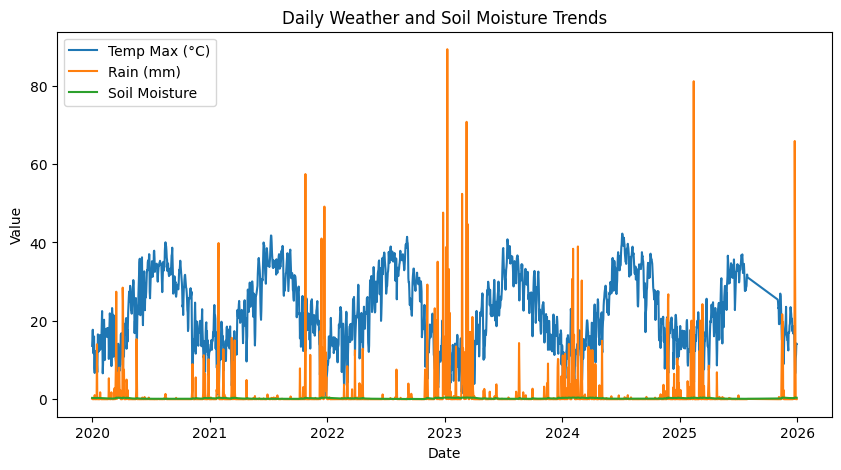

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Temperature, precipitation, soil moisture over time
plt.figure(figsize=(10,5))
plt.plot(df_merged['date'], df_merged['T2M_MAX'], label='Temp Max (°C)')
plt.plot(df_merged['date'], df_merged['PRECTOTCORR'], label='Rain (mm)')
plt.plot(df_merged['date'], df_merged['v_soilm_0_10cm'], label='Soil Moisture')
plt.legend()
plt.title('Daily Weather and Soil Moisture Trends')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

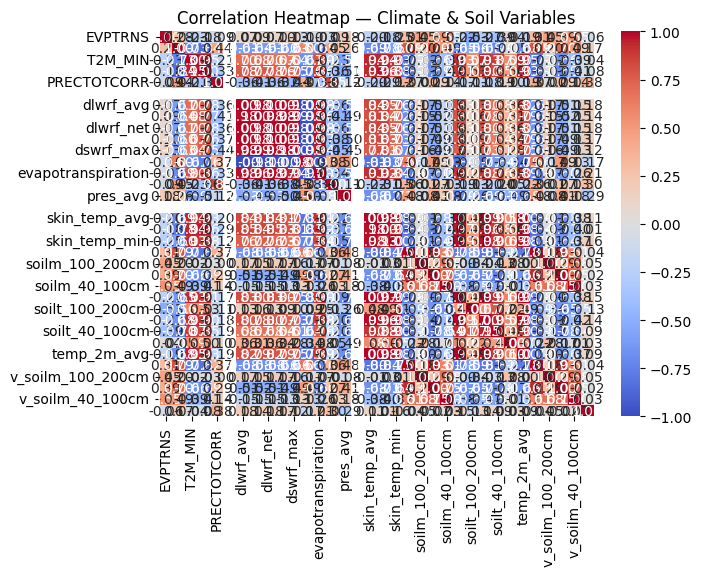

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

num_df = df_merged.select_dtypes(include='number')

plt.figure(figsize=(7,5))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap — Climate & Soil Variables")
plt.show()


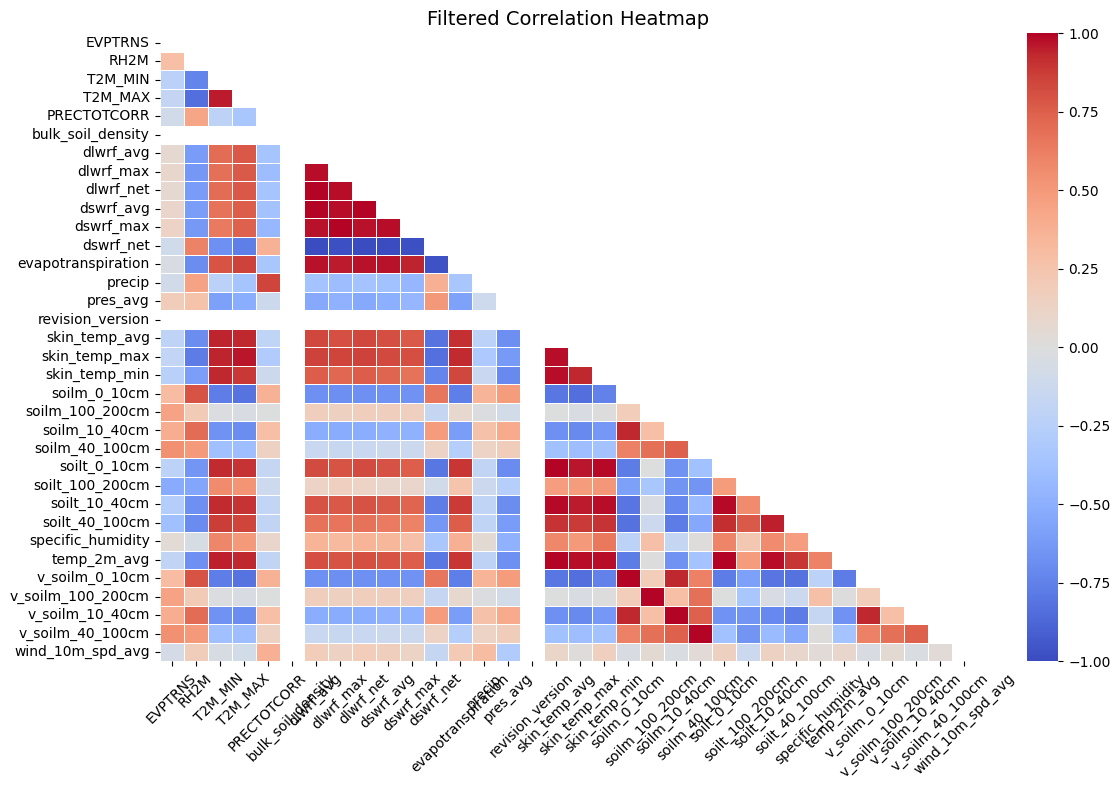

In [121]:
import numpy as np

num_df = df_merged.select_dtypes(include='number')
corr = num_df.corr()

threshold = 0.5
corr_filtered = corr[(corr.abs() >= threshold)]

plt.figure(figsize=(12,8))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title("Filtered Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

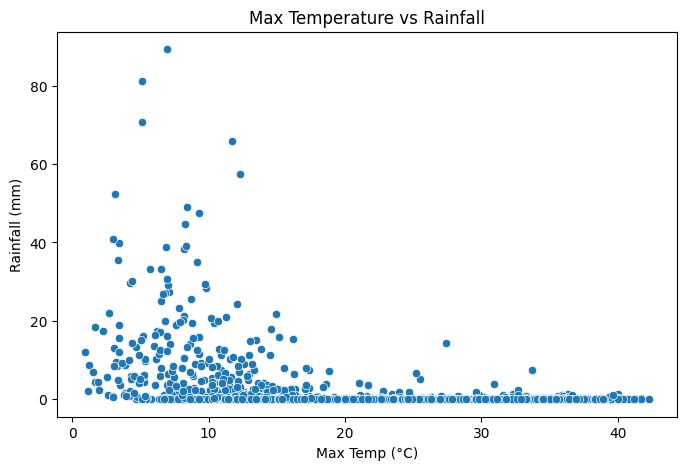

In [122]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='T2M_MAX', y='PRECTOTCORR', data=df_merged)
plt.title('Max Temperature vs Rainfall')
plt.xlabel('Max Temp (°C)')
plt.ylabel('Rainfall (mm)')
plt.show()


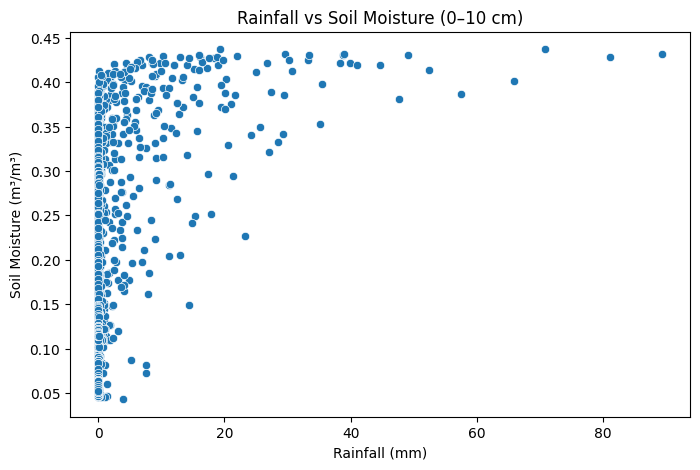

In [123]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='PRECTOTCORR', y='v_soilm_0_10cm', data=df_merged)
plt.title('Rainfall vs Soil Moisture (0–10 cm)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Soil Moisture (m³/m³)')
plt.show()

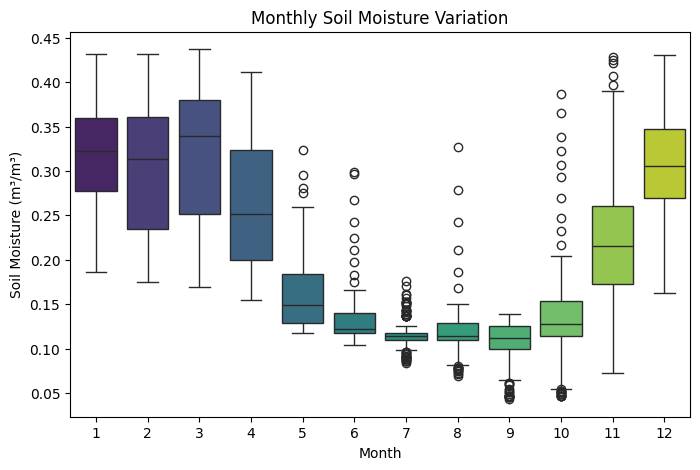

In [124]:
df_merged['month'] = df_merged['date'].dt.month
plt.figure(figsize=(8,5))
sns.boxplot(x='month', y='v_soilm_0_10cm', data=df_merged, palette='viridis')
plt.title('Monthly Soil Moisture Variation')
plt.xlabel('Month')
plt.ylabel('Soil Moisture (m³/m³)')
plt.show()

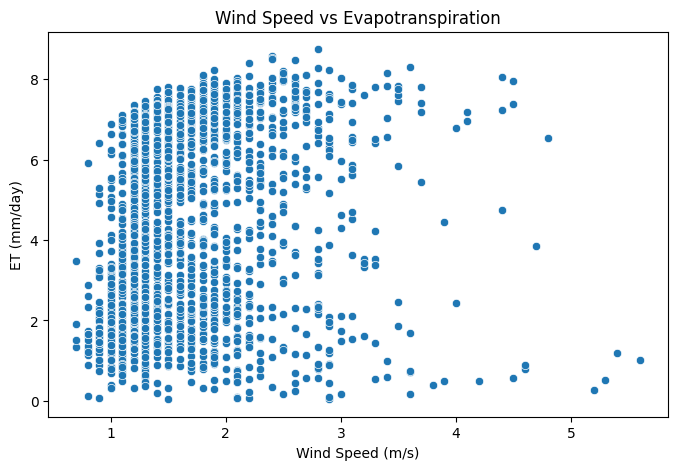

In [125]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='wind_10m_spd_avg', y='evapotranspiration', data=df_merged)
plt.title('Wind Speed vs Evapotranspiration')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('ET (mm/day)')
plt.show()

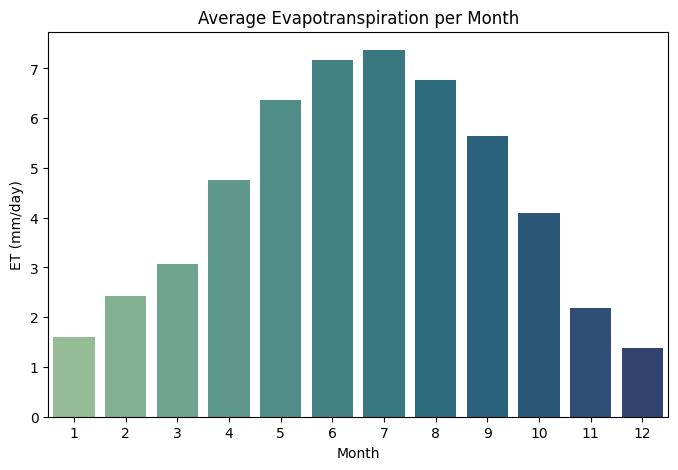

In [126]:
et_month = df_merged.groupby('month')['evapotranspiration'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='month', y='evapotranspiration', data=et_month, palette='crest')
plt.title('Average Evapotranspiration per Month')
plt.xlabel('Month')
plt.ylabel('ET (mm/day)')
plt.show()

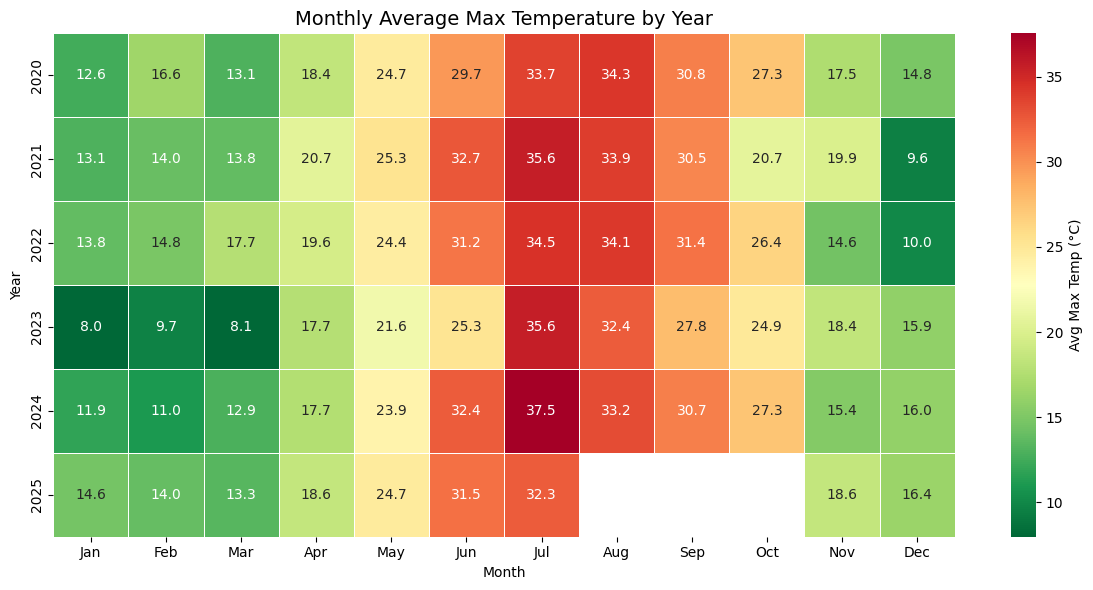

In [127]:
df_merged['year'] = df_merged['date'].dt.year
df_merged['month'] = df_merged['date'].dt.month

pivot_temp = df_merged.pivot_table(
    values='T2M_MAX',
    index='year',
    columns='month',
    aggfunc='mean'
)

pivot_temp.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                      'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_temp,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': 'Avg Max Temp (°C)'}
)
plt.title('Monthly Average Max Temperature by Year', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig('viz9_temp_heatmap_year.png', dpi=150)
plt.show()

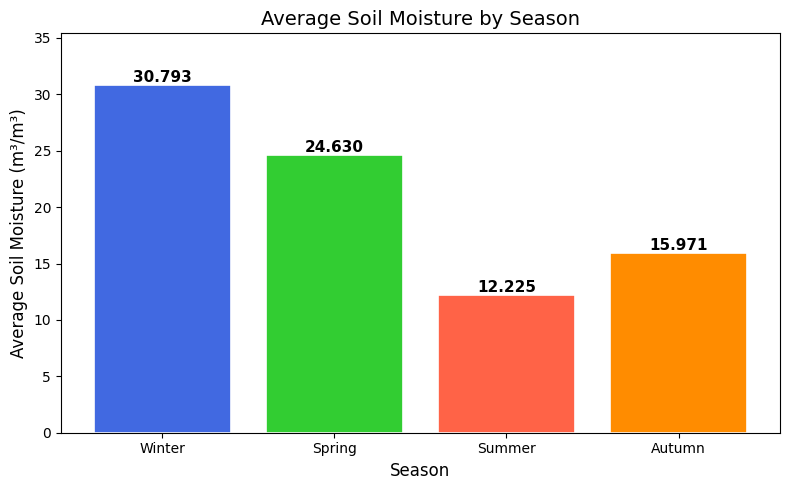

In [128]:
df_merged['season'] = df_merged['date'].dt.month.map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring', 5:'Spring',
    6:'Summer',  7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn'
})

# Get soil moisture column name
soil_col = [c for c in df_merged.columns if 'soilm' in c.lower() or 'gwettop' in c.lower()][0]

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
seasonal_avg = df_merged.groupby('season')[soil_col].mean().reindex(season_order)

plt.figure(figsize=(8, 5))
colors = ['royalblue', 'limegreen', 'tomato', 'darkorange']
bars = plt.bar(season_order, seasonal_avg.values, color=colors, edgecolor='white', linewidth=1.2)

# Add value labels on top of each bar
for bar, val in zip(bars, seasonal_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Soil Moisture (m³/m³)', fontsize=12)
plt.title('Average Soil Moisture by Season', fontsize=14)
plt.ylim(0, seasonal_avg.max() * 1.15)
plt.tight_layout()
plt.savefig('viz7_seasonal_soil_moisture.png', dpi=150)
plt.show()

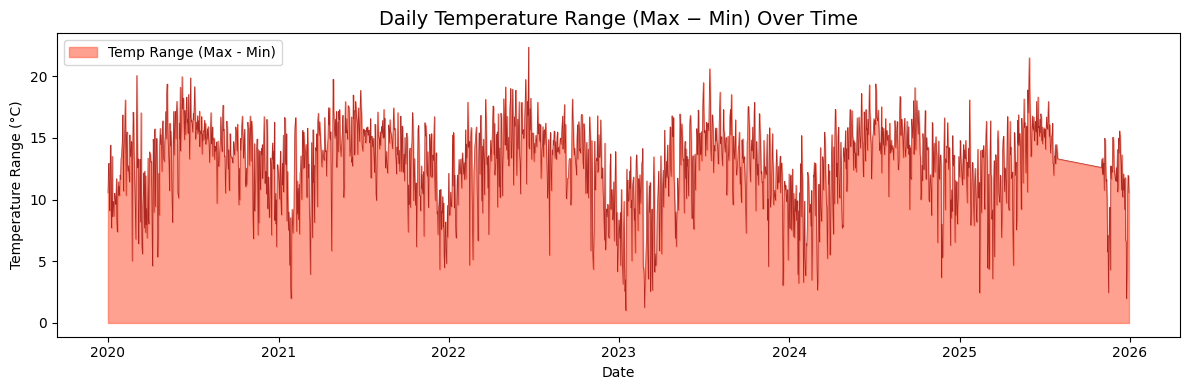

In [129]:
df_merged['temp_range'] = df_merged['T2M_MAX'] - df_merged['T2M_MIN']

plt.figure(figsize=(12, 4))
plt.fill_between(df_merged['date'], df_merged['temp_range'],
                 alpha=0.6, color='tomato', label='Temp Range (Max - Min)')
plt.plot(df_merged['date'], df_merged['temp_range'],
         color='darkred', linewidth=0.5, alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Temperature Range (°C)')
plt.title('Daily Temperature Range (Max − Min) Over Time', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('viz7_temp_range.png', dpi=150)
plt.show()

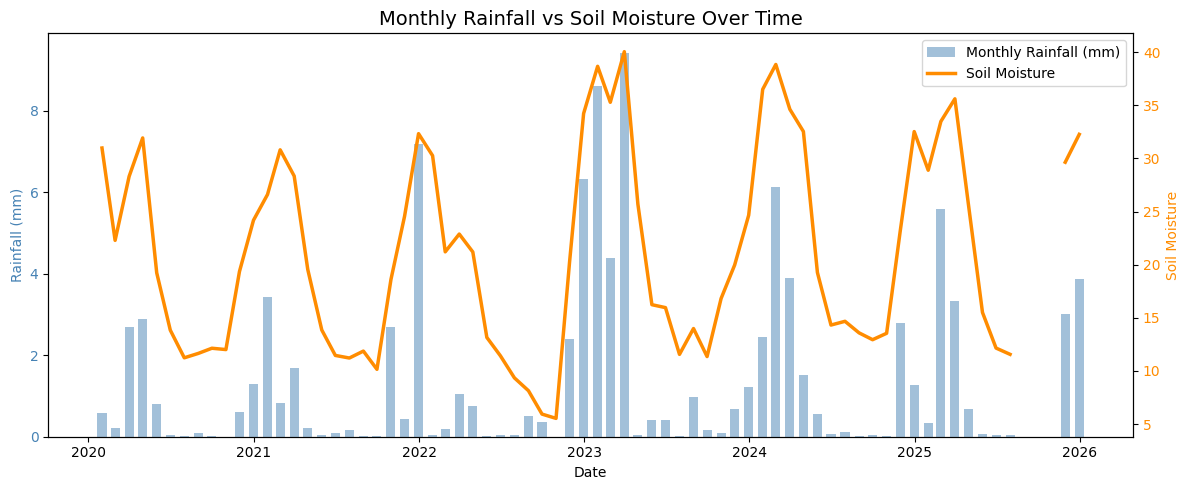

In [130]:
numeric_cols = df_merged.select_dtypes(include='number').columns.tolist()
df_monthly = (
    df_merged[['date'] + numeric_cols]
    .set_index('date')
    .resample('ME')
    .mean()
    .reset_index()
)

soil_col = [c for c in df_monthly.columns
            if 'soilm' in c.lower() or 'gwettop' in c.lower() or 'gwetroot' in c.lower()][0]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(df_monthly['date'], df_monthly['PRECTOTCORR'],
        color='steelblue', alpha=0.5, label='Monthly Rainfall (mm)', width=20)
ax1.set_xlabel('Date')
ax1.set_ylabel('Rainfall (mm)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(df_monthly['date'], df_monthly[soil_col],
         color='darkorange', linewidth=2.5, label=f'Soil Moisture')
ax2.set_ylabel('Soil Moisture', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Monthly Rainfall vs Soil Moisture Over Time', fontsize=14)
plt.tight_layout()
plt.savefig('viz10_dual_axis.png', dpi=150)
plt.show()

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('/content/merged_smart_water (1).csv', parse_dates=['date'])
print('Dataset shape:', df.shape)
df.head(3)

Dataset shape: (2031, 38)


,EVPTRNS,RH2M,T2M_MIN,T2M_MAX,PRECTOTCORR,date,bulk_soil_density,dlwrf_avg,dlwrf_max,dlwrf_net,...,soilt_40_100cm,specific_humidity,temp_2m_avg,timestamp_local,timestamp_utc,v_soilm_0_10cm,v_soilm_100_200cm,v_soilm_10_40cm,v_soilm_40_100cm,wind_10m_spd_avg
0,0.48,65.03,3.05,13.60,0.10,2020-01-01,1520,17.08,70,17.08,...,10.4,0.00537,9.4,2020-01-01T00:00:00,2020-01-01T00:00:00,0.334,0.263,0.335,0.249,1.3
1,0.64,63.18,2.89,15.37,0.03,2020-01-02,1520,13.33,50,13.33,...,10.4,0.00600,8.4,2020-01-02T00:00:00,2020-01-02T00:00:00,0.329,0.263,0.331,0.249,1.0
2,0.70,51.74,4.78,17.73,0.00,2020-01-03,1520,19.17,75,19.17,...,10.4,0.00543,10.0,2020-01-03T00:00:00,2020-01-03T00:00:00,0.326,0.263,0.327,0.249,0.8


In [132]:
# Select quantitative columns only
df_pca_raw = df.select_dtypes(include=[np.number]).copy()
df_pca_raw = df_pca_raw.loc[:, df_pca_raw.std() > 0.01]
df_pca_raw.dropna(inplace=True)

print('Shape after prep:', df_pca_raw.shape)
print('Columns used:', list(df_pca_raw.columns))
df_pca_raw.head(3)

Shape after prep: (2031, 31)
Columns used: ['EVPTRNS', 'RH2M', 'T2M_MIN', 'T2M_MAX', 'PRECTOTCORR', 'dlwrf_avg', 'dlwrf_max', 'dlwrf_net', 'dswrf_avg', 'dswrf_max', 'dswrf_net', 'evapotranspiration', 'precip', 'pres_avg', 'skin_temp_avg', 'skin_temp_max', 'skin_temp_min', 'soilm_0_10cm', 'soilm_100_200cm', 'soilm_10_40cm', 'soilm_40_100cm', 'soilt_0_10cm', 'soilt_100_200cm', 'soilt_10_40cm', 'soilt_40_100cm', 'temp_2m_avg', 'v_soilm_0_10cm', 'v_soilm_100_200cm', 'v_soilm_10_40cm', 'v_soilm_40_100cm', 'wind_10m_spd_avg']


,EVPTRNS,RH2M,T2M_MIN,T2M_MAX,PRECTOTCORR,dlwrf_avg,dlwrf_max,dlwrf_net,dswrf_avg,dswrf_max,...,soilt_0_10cm,soilt_100_200cm,soilt_10_40cm,soilt_40_100cm,temp_2m_avg,v_soilm_0_10cm,v_soilm_100_200cm,v_soilm_10_40cm,v_soilm_40_100cm,wind_10m_spd_avg
0,0.48,65.03,3.05,13.60,0.10,17.08,70,17.08,113.75,465,...,8.0,16.3,7.7,10.4,9.4,0.334,0.263,0.335,0.249,1.3
1,0.64,63.18,2.89,15.37,0.03,13.33,50,13.33,83.33,315,...,7.4,15.9,7.7,10.4,8.4,0.329,0.263,0.331,0.249,1.0
2,0.70,51.74,4.78,17.73,0.00,19.17,75,19.17,119.58,505,...,8.4,15.9,8.4,10.4,10.0,0.326,0.263,0.327,0.249,0.8


In [133]:
# Normalize with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca_raw)

df_scaled = pd.DataFrame(X_scaled, columns=df_pca_raw.columns)
print('After StandardScaler — mean ≈ 0, std ≈ 1:')
df_scaled.describe().loc[['mean', 'std']].round(3)

After StandardScaler — mean ≈ 0, std ≈ 1:


,EVPTRNS,RH2M,T2M_MIN,T2M_MAX,PRECTOTCORR,dlwrf_avg,dlwrf_max,dlwrf_net,dswrf_avg,dswrf_max,...,soilt_0_10cm,soilt_100_200cm,soilt_10_40cm,soilt_40_100cm,temp_2m_avg,v_soilm_0_10cm,v_soilm_100_200cm,v_soilm_10_40cm,v_soilm_40_100cm,wind_10m_spd_avg
mean,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [134]:
# 3a PCA with n_components = 2
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

var2 = pca2.explained_variance_ratio_
cum_var2 = np.cumsum(var2)

print('=== PCA  n=2 ===')
print(f'PC1 variance: {var2[0]*100:.2f}%')
print(f'PC2 variance: {var2[1]*100:.2f}%')
print(f'Total retained: {cum_var2[-1]*100:.2f}%')

=== PCA  n=2 ===
PC1 variance: 58.80%
PC2 variance: 16.41%
Total retained: 75.20%


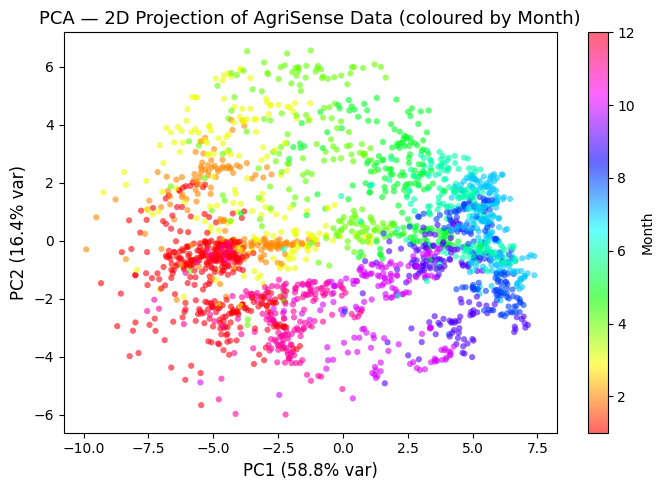

In [135]:
# 2D Scatter Visualisatio
month_col = df.loc[df_pca_raw.index, 'date'].dt.month.values

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(X_pca2[:, 0], X_pca2[:, 1],
                c=month_col, cmap='hsv', alpha=0.6, s=20, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Month')
ax.set_xlabel(f'PC1 ({var2[0]*100:.1f}% var)', fontsize=12)
ax.set_ylabel(f'PC2 ({var2[1]*100:.1f}% var)', fontsize=12)
ax.set_title('PCA — 2D Projection of AgriSense Data (coloured by Month)', fontsize=13)
plt.tight_layout()
plt.savefig('pca_2d.png', dpi=150)
plt.show()

In [136]:
#3b PCA with n_components = 3
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

var3 = pca3.explained_variance_ratio_
cum_var3 = np.cumsum(var3)

print('PCA  n=3 ')
for i, (v, cv) in enumerate(zip(var3, cum_var3), 1):
    print(f'PC{i}: {v*100:.2f}%  (cumulative: {cv*100:.2f}%)')
print(f'\nTotal information retained in 3D: {cum_var3[-1]*100:.2f}%')

PCA  n=3 
PC1: 58.80%  (cumulative: 58.80%)
PC2: 16.41%  (cumulative: 75.20%)
PC3: 8.10%  (cumulative: 83.30%)

Total information retained in 3D: 83.30%


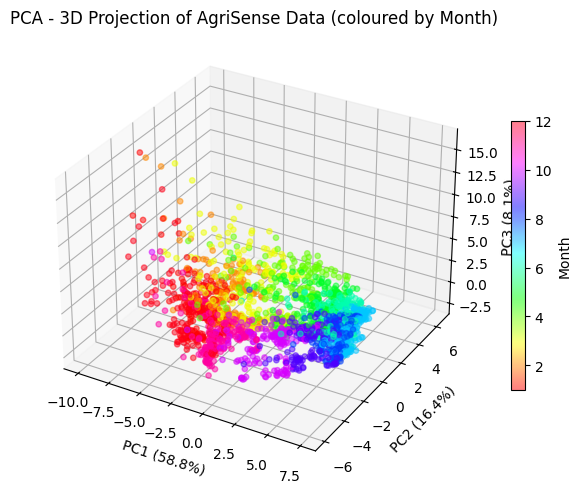

In [137]:
# 3D Scatter Visualisation
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2],
               c=month_col, cmap='hsv', alpha=0.5, s=15)
fig.colorbar(p, ax=ax, label='Month', shrink=0.6)
ax.set_xlabel(f'PC1 ({var3[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var3[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({var3[2]*100:.1f}%)')
ax.set_title('PCA - 3D Projection of AgriSense Data (coloured by Month)')
plt.tight_layout()
plt.savefig('pca_3d.png', dpi=150)
plt.show()

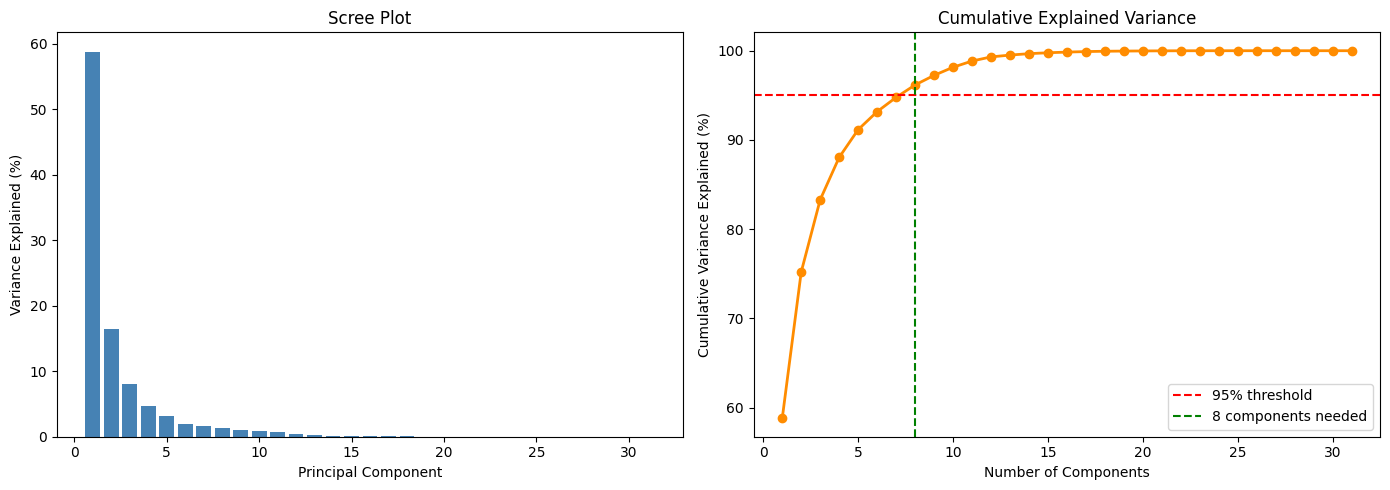


Components needed to retain ≥95% variance: 8
   Cumulative variance at 8 components: 96.16%


In [138]:
# Scree Plot  Cumulative Variance (find 95% threshold)
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cum_var_full = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = int(np.argmax(cum_var_full >= 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_ * 100, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')

axes[1].plot(range(1, len(cum_var_full)+1), cum_var_full * 100,
             marker='o', color='darkorange', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].axvline(n_95, color='green', linestyle='--', label=f'{n_95} components needed')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150)
plt.show()
print(f'\nComponents needed to retain ≥95% variance: {n_95}')
print(f'   Cumulative variance at {n_95} components: {cum_var_full[n_95-1]*100:.2f}%')

Top 3 Eigenvalues
  PC1 eigenvalue: 18.2361
  PC2 eigenvalue: 5.0888
  PC3 eigenvalue: 2.5115


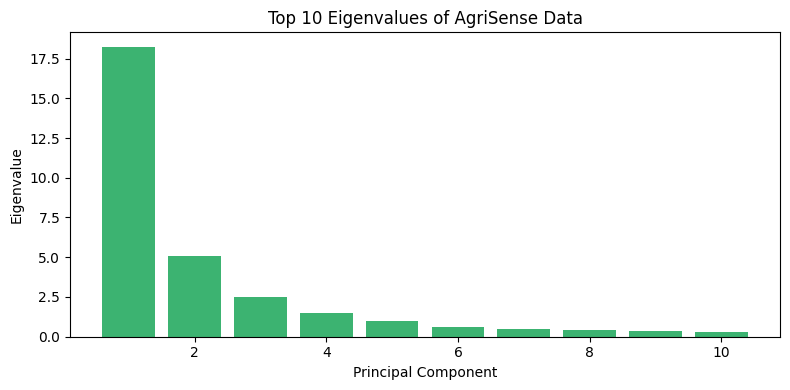

In [139]:
# Top 3 Eigenvalues
eigenvalues = pca_full.explained_variance_

print('Top 3 Eigenvalues')
for i, ev in enumerate(eigenvalues[:3], 1):
    print(f'  PC{i} eigenvalue: {ev:.4f}')

plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), eigenvalues[:10], color='mediumseagreen')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title('Top 10 Eigenvalues of AgriSense Data')
plt.tight_layout()
plt.savefig('pca_eigenvalues.png', dpi=150)
plt.show()

CLustering

In [140]:
# Data Prep — create seasonal labels
df_cl = df.copy()
df_cl['month'] = df_cl['date'].dt.month
df_cl['season'] = df_cl['month'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring', 4:'Spring', 5:'Spring',
    6:'Summer', 7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn',11:'Autumn'
})

feature_cols = df_cl.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if df_cl[c].std() > 0.01]

df_cl_clean = df_cl[feature_cols + ['season']].dropna()
labels_season = df_cl_clean['season'].values
X_cl = df_cl_clean[feature_cols].values

scaler_cl = StandardScaler()
X_cl_scaled = scaler_cl.fit_transform(X_cl)

print(f'Feature matrix shape: {X_cl_scaled.shape}')
print(f'Unique labels: {np.unique(labels_season)}')

Feature matrix shape: (2031, 32)
Unique labels: ['Autumn' 'Spring' 'Summer' 'Winter']


In [141]:
# Reduce to 2D and 3D via PCA for clustering
pca_cl = PCA(n_components=3, random_state=42)
X_cl_3d = pca_cl.fit_transform(X_cl_scaled)
retained = pca_cl.explained_variance_ratio_.sum() * 100
print(f'Variance retained after 3D PCA: {retained:.2f}%')

pca_cl2 = PCA(n_components=2, random_state=42)
X_cl_2d = pca_cl2.fit_transform(X_cl_scaled)

season_map = {'Winter':0, 'Spring':1, 'Summer':2, 'Autumn':3}
season_colors = ['royalblue','limegreen','tomato','darkorange']
season_palette = {s: season_colors[i] for s, i in season_map.items()}

Variance retained after 3D PCA: 81.97%


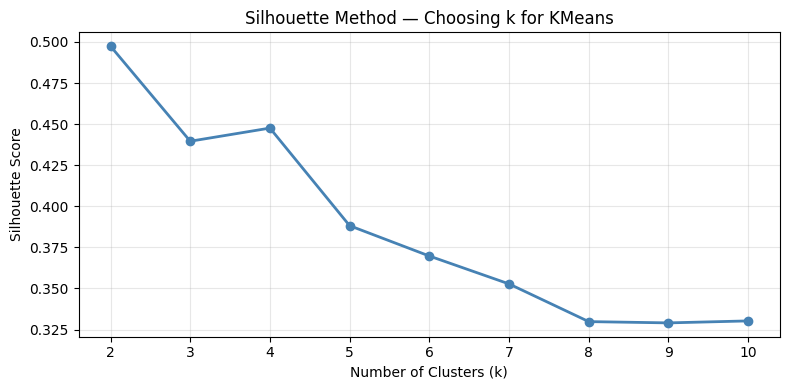


Top-3 smart k values: [2, 3, 4]
  k=2  silhouette=0.4974
  k=3  silhouette=0.4396
  k=4  silhouette=0.4476


In [142]:
# A) KMeans Silhouette Method to pick k
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_cl_3d)
    sil_scores[k] = silhouette_score(X_cl_3d, labels_k)

plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()),
         marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method — Choosing k for KMeans')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_silhouette.png', dpi=150)
plt.show()

sorted_k = sorted(sil_scores, key=sil_scores.get, reverse=True)
best_ks = sorted(sorted_k[:3])
print(f'\nTop-3 smart k values: {best_ks}')
for k in best_ks:
    print(f'  k={k}  silhouette={sil_scores[k]:.4f}')

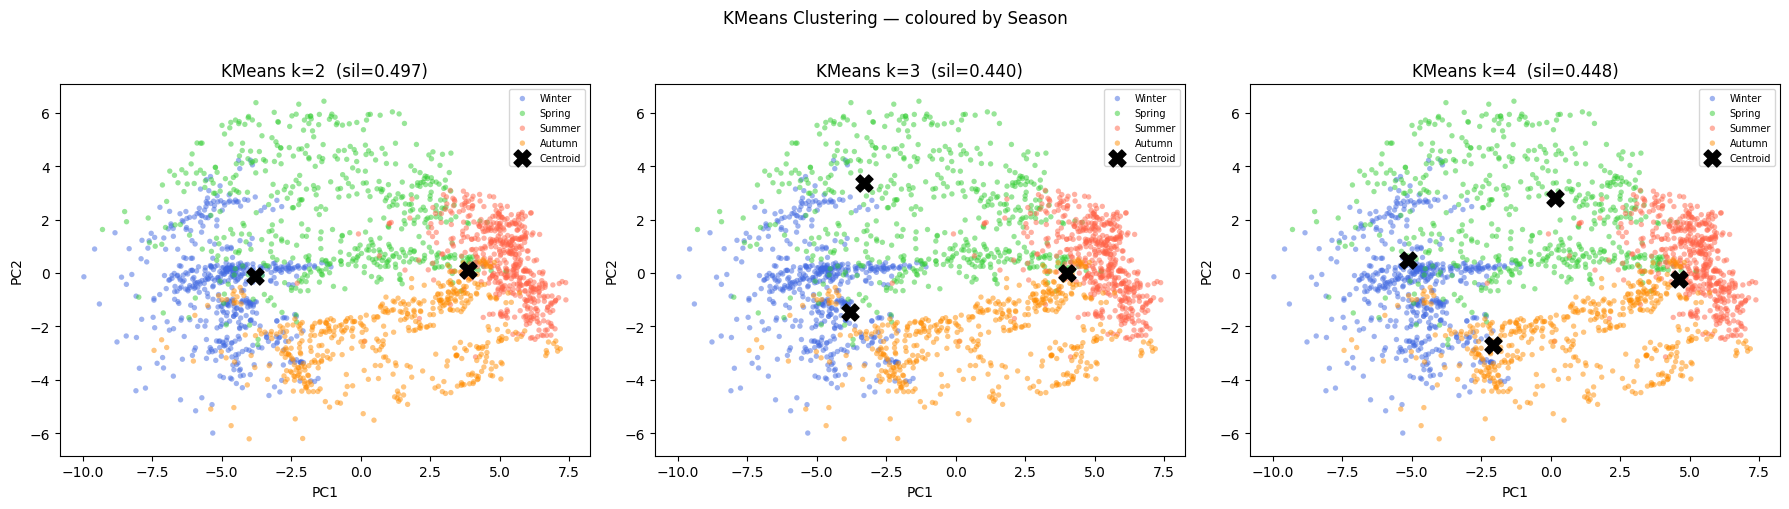

In [143]:
# KMeans plots for each best k
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, k in zip(axes, best_ks):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_cl_2d)
    centroids = km.cluster_centers_

    for season, col in season_palette.items():
        mask = labels_season == season
        ax.scatter(X_cl_2d[mask, 0], X_cl_2d[mask, 1],
                   c=col, s=15, alpha=0.5, label=season, edgecolors='none')

    ax.scatter(centroids[:, 0], centroids[:, 1],
               c='black', marker='X', s=150, zorder=5, label='Centroid')
    ax.set_title(f'KMeans k={k}  (sil={sil_scores[k]:.3f})')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=7)

plt.suptitle('KMeans Clustering — coloured by Season', y=1.01)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150)
plt.show()

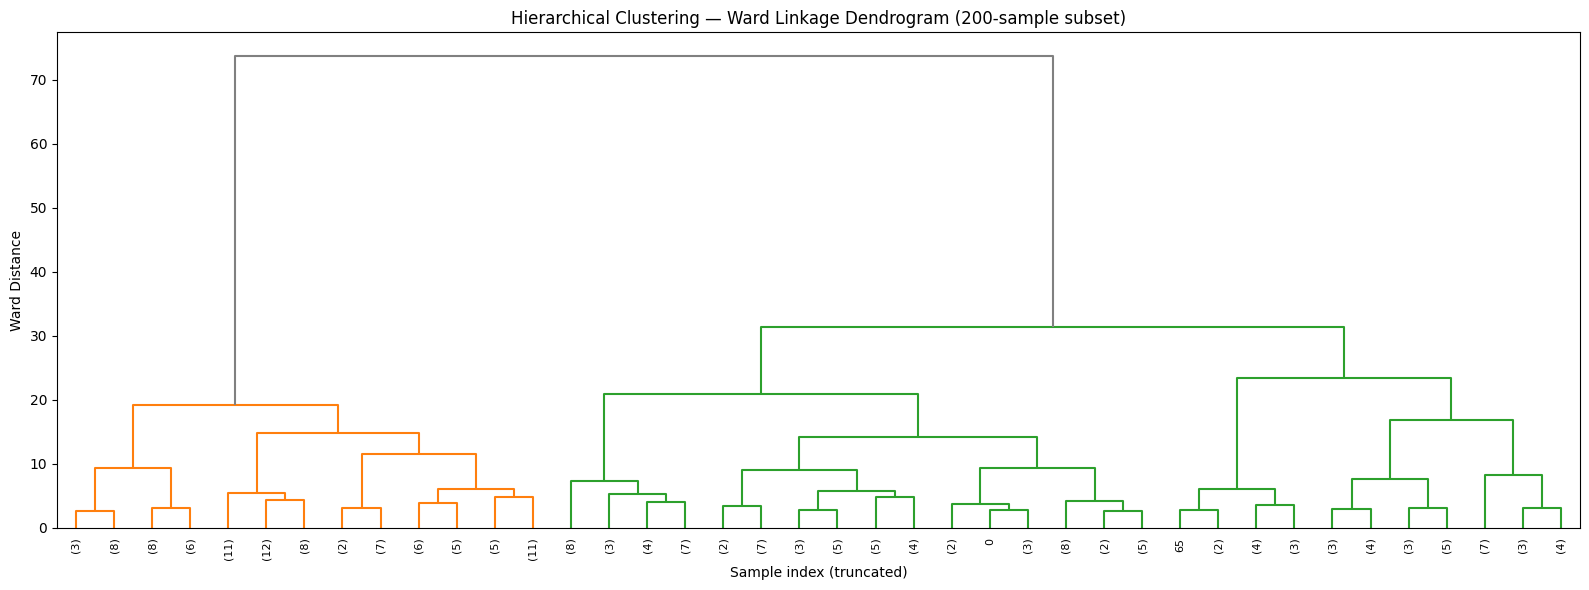

In [144]:
# B) Hierarchical Clustering - Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

np.random.seed(42)
sample_idx = np.random.choice(len(X_cl_3d), size=200, replace=False)
X_sample = X_cl_3d[sample_idx]

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=40,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.7 * max(Z[:, 2]),
           above_threshold_color='gray')
ax.set_title('Hierarchical Clustering — Ward Linkage Dendrogram (200-sample subset)')
ax.set_xlabel('Sample index (truncated)')
ax.set_ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()

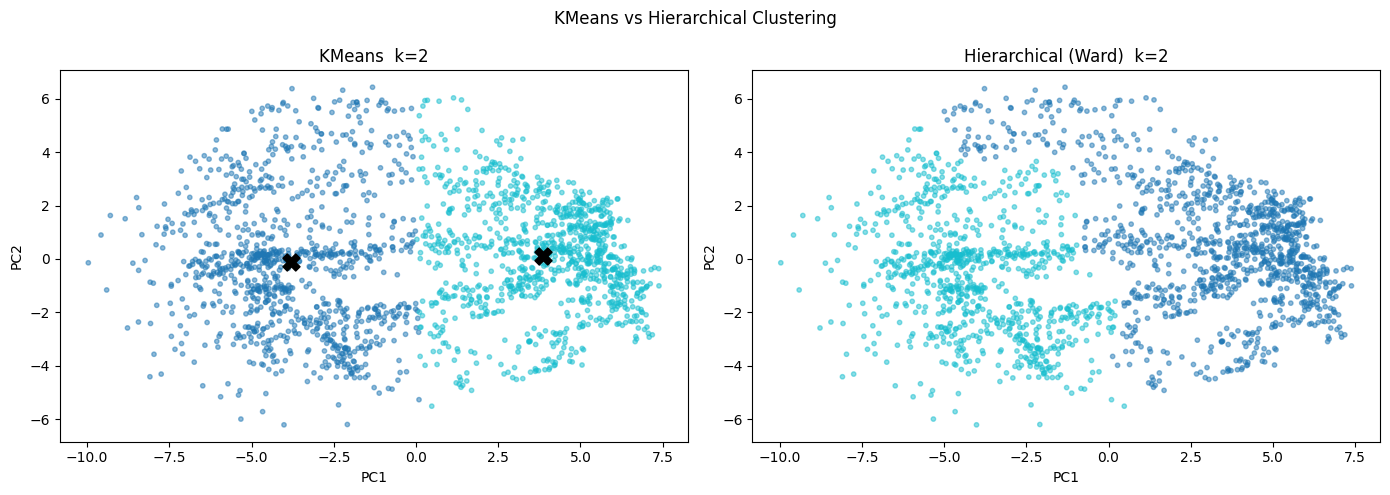

In [145]:
# KMeans vs Hierarchical side-by-side
best_k = best_ks[0]
hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hc_labels = hc.fit_predict(X_cl_2d)

km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km_best.fit_predict(X_cl_2d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_cl_2d[:,0], X_cl_2d[:,1], c=km_labels, cmap='tab10', s=10, alpha=0.5)
axes[0].scatter(km_best.cluster_centers_[:,0], km_best.cluster_centers_[:,1],
                c='black', marker='X', s=150, zorder=5)
axes[0].set_title(f'KMeans  k={best_k}')

axes[1].scatter(X_cl_2d[:,0], X_cl_2d[:,1], c=hc_labels, cmap='tab10', s=10, alpha=0.5)
axes[1].set_title(f'Hierarchical (Ward)  k={best_k}')

for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('KMeans vs Hierarchical Clustering')
plt.tight_layout()
plt.savefig('kmeans_vs_hierarchical.png', dpi=150)
plt.show()

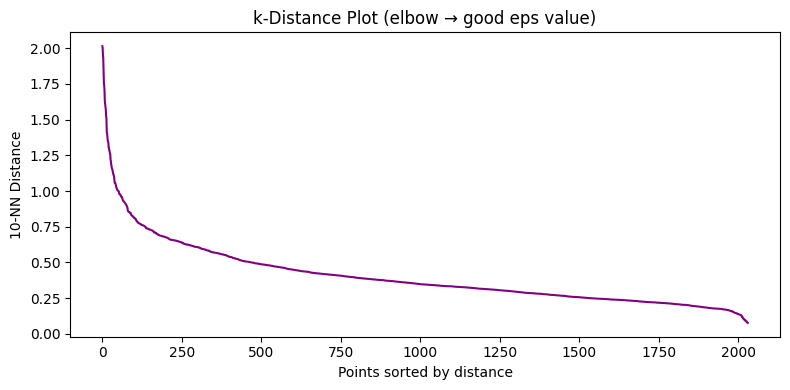

In [146]:
# C) DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

min_samples = 10
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_cl_2d)
distances, _ = nbrs.kneighbors(X_cl_2d)
k_dist = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_dist, color='purple')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples}-NN Distance')
plt.title('k-Distance Plot (elbow → good eps value)')
plt.tight_layout()
plt.show()

Clusters found: 8
Noise points  : 250 (12.3%)


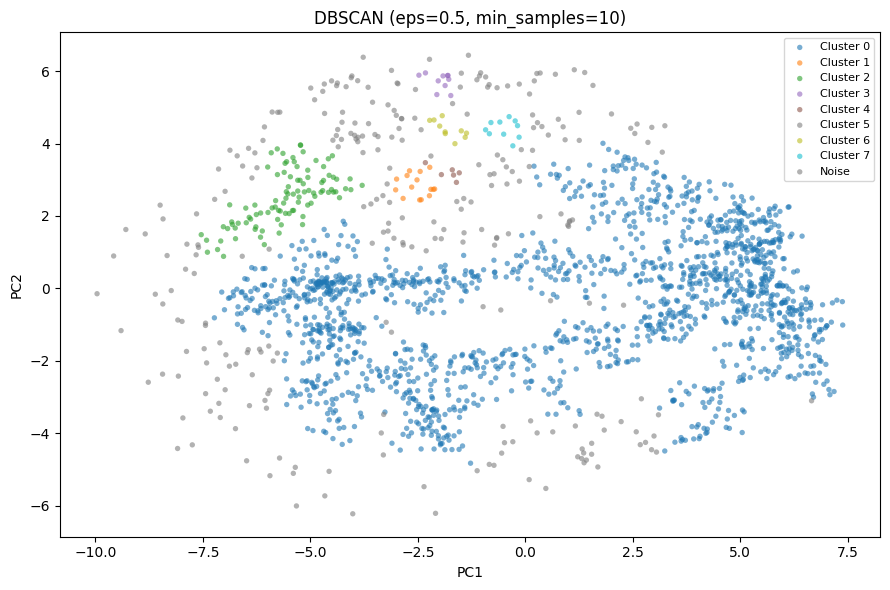

In [147]:
# Running DBSCAN
eps_val = 0.5
db = DBSCAN(eps=eps_val, min_samples=min_samples)
db_labels = db.fit_predict(X_cl_2d)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = np.sum(db_labels == -1)
print(f'Clusters found: {n_clusters_db}')
print(f'Noise points  : {n_noise} ({n_noise/len(db_labels)*100:.1f}%)')

plt.figure(figsize=(9, 6))
unique_labels = set(db_labels)
palette = cm.get_cmap('tab10', max(unique_labels)+1)

for lbl in unique_labels:
    mask = db_labels == lbl
    col = 'gray' if lbl == -1 else palette(lbl)
    label_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    plt.scatter(X_cl_2d[mask,0], X_cl_2d[mask,1],
                c=[col], s=15, alpha=0.6, label=label_name, edgecolors='none')

plt.legend(fontsize=8)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'DBSCAN (eps={eps_val}, min_samples={min_samples})')
plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=150)
plt.show()

ARM

In [148]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="datetime.datetime.utcnow\\(\\) is deprecated",
    category=DeprecationWarning
)

In [149]:
# ARM — Data Prep
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

df_arm = df.copy()
df_arm['month'] = df_arm['date'].dt.month
df_arm['season'] = df_arm['month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring', 5:'Spring',
    6:'Summer',  7:'Summer', 8:'Summer',
    9:'Autumn', 10:'Autumn',11:'Autumn'
})

def bin_col_safe(series, col_name, q=3):
    """
    Safely bin a column into q quantile-based categories.
    Falls back to fewer bins if not enough unique values.
    """
    labels_map = {
        3: [f'{col_name}_Low', f'{col_name}_Mid', f'{col_name}_High'],
        2: [f'{col_name}_Low', f'{col_name}_High'],
        1: [f'{col_name}_Low']
    }
    for n_bins in [q, 2, 1]:
        try:
            labels = labels_map[n_bins]
            return pd.qcut(series, q=n_bins, labels=labels, duplicates='drop')
        except ValueError:
            continue
    return pd.Series([f'{col_name}_Low'] * len(series), index=series.index)

arm_cols = {
    'T2M_MAX'     : 'Temp',
    'PRECTOTCORR' : 'Rain',
    'RH2M'        : 'Humidity',
    'EVPTRNS'     : 'ET',
}

sm_col = [c for c in df_arm.columns if 'soilm_0_10' in c or 'GWETTOP' in c]
if sm_col:
    arm_cols[sm_col[0]] = 'SoilM'

for orig_col, short_name in arm_cols.items():
    if orig_col in df_arm.columns:
        df_arm[short_name] = bin_col_safe(df_arm[orig_col], short_name, q=3)

item_cols = ['season'] + [v for v in arm_cols.values() if v in df_arm.columns]
transactions = df_arm[item_cols].dropna().astype(str).values.tolist()

print(f'Total transactions : {len(transactions)}')
print(f'Items per transaction: {len(transactions[0])}')
print('Sample transaction :', transactions[0])

Total transactions : 2031
Items per transaction: 6
Sample transaction : ['Winter', 'Temp_Low', 'Rain_Low', 'Humidity_High', 'ET_High', 'SoilM_High']


In [150]:
# One-hot encode for mlxtend
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)
print('One-hot encoded shape:', df_te.shape)
df_te.head(3)

One-hot encoded shape: (2031, 16)


,Autumn,ET_High,ET_Low,Humidity_High,Humidity_Low,Humidity_Mid,Rain_Low,SoilM_High,SoilM_Low,SoilM_Mid,Spring,Summer,Temp_High,Temp_Low,Temp_Mid,Winter
0,False,True,False,True,False,False,True,True,False,False,False,False,False,True,False,True
1,False,True,False,True,False,False,True,True,False,False,False,False,False,True,False,True
2,False,True,False,False,False,True,True,True,False,False,False,False,False,False,True,True


In [151]:
# Run Apriori + Generate Rules
min_sup  = 0.05
min_conf = 0.4

frequent_itemsets = apriori(df_te, min_support=min_sup, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='confidence',
                          min_threshold=min_conf, num_itemsets=len(frequent_itemsets))

print(f'Frequent itemsets : {len(frequent_itemsets)}')
print(f'Rules generated   : {len(rules)}')

Frequent itemsets : 349
Rules generated   : 1904


In [152]:
# Top 15 by Support
display_cols = ['antecedents','consequents','support','confidence','lift']
print('Top 15 Rules by SUPPORT')
print(rules.sort_values('support', ascending=False).head(15)[display_cols].to_string(index=False))

Top 15 Rules by SUPPORT
        antecedents        consequents  support  confidence    lift
           (ET_Low)         (Rain_Low) 0.503200    1.000000 1.00000
         (Rain_Low)           (ET_Low) 0.503200    0.503200 1.00000
          (ET_High)         (Rain_Low) 0.496800    1.000000 1.00000
         (Rain_Low)          (ET_High) 0.496800    0.496800 1.00000
         (Temp_Low)         (Rain_Low) 0.334318    1.000000 1.00000
        (SoilM_Low)         (Rain_Low) 0.333826    1.000000 1.00000
    (Humidity_High)         (Rain_Low) 0.333333    1.000000 1.00000
       (SoilM_High)         (Rain_Low) 0.333333    1.000000 1.00000
     (Humidity_Mid)         (Rain_Low) 0.333333    1.000000 1.00000
        (Temp_High)         (Rain_Low) 0.333333    1.000000 1.00000
     (Humidity_Low)         (Rain_Low) 0.333333    1.000000 1.00000
        (SoilM_Mid)         (Rain_Low) 0.332841    1.000000 1.00000
         (Temp_Mid)         (Rain_Low) 0.332349    1.000000 1.00000
(ET_Low, SoilM_Low)     

In [153]:
# Top 15 by Confidence
print('Top 15 Rules by CONFIDENCE')
print(rules.sort_values('confidence', ascending=False).head(15)[display_cols].to_string(index=False))

Top 15 Rules by CONFIDENCE
                                antecedents        consequents  support  confidence    lift
     (Temp_High, Summer, ET_Low, SoilM_Low)         (Rain_Low) 0.168390         1.0 1.00000
                             (Humidity_Low)         (Rain_Low) 0.333333         1.0 1.00000
                (Temp_High, Autumn, ET_Low)         (Rain_Low) 0.084687         1.0 1.00000
(Temp_High, Autumn, Humidity_Low, Rain_Low)           (ET_Low) 0.073855         1.0 1.98728
              (Temp_High, Autumn, Rain_Low)           (ET_Low) 0.084687         1.0 1.98728
                        (Temp_High, Autumn) (ET_Low, Rain_Low) 0.084687         1.0 1.98728
                 (Autumn, ET_Low, Temp_Mid)         (Rain_Low) 0.079271         1.0 1.00000
   (Temp_High, Autumn, Rain_Low, SoilM_Low)           (ET_Low) 0.070409         1.0 1.98728
           (ET_Low, Humidity_Low, Temp_Mid)         (Rain_Low) 0.052191         1.0 1.00000
                             (Humidity_Mid)         (

In [154]:
# Top 15 by Lift
print('Top 15 Rules by LIFT')
print(rules.sort_values('lift', ascending=False).head(15)[display_cols].to_string(index=False))

Top 15 Rules by LIFT
                                antecedents                              consequents  support  confidence     lift
   (ET_High, SoilM_Mid, Rain_Low, Temp_Mid)                   (Humidity_Mid, Spring) 0.059577    0.463602 4.379417
             (ET_High, SoilM_Mid, Temp_Mid)                   (Humidity_Mid, Spring) 0.059577    0.463602 4.379417
             (ET_High, SoilM_Mid, Temp_Mid)         (Rain_Low, Humidity_Mid, Spring) 0.059577    0.463602 4.379417
                     (Humidity_Mid, Spring) (ET_High, SoilM_Mid, Rain_Low, Temp_Mid) 0.059577    0.562791 4.379417
           (Rain_Low, Humidity_Mid, Spring)           (ET_High, SoilM_Mid, Temp_Mid) 0.059577    0.562791 4.379417
                     (Humidity_Mid, Spring)           (ET_High, SoilM_Mid, Temp_Mid) 0.059577    0.562791 4.379417
           (Humidity_Mid, Spring, Temp_Mid)                     (ET_High, SoilM_Mid) 0.059577    0.785714 3.901677
 (Rain_Low, Humidity_Mid, Spring, Temp_Mid)                

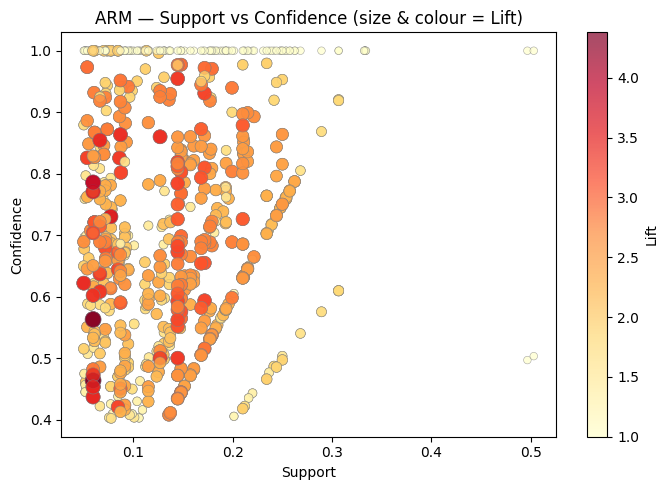

In [155]:

# Scatter: Support vs Confidence (size = Lift)
plt.figure(figsize=(7, 5))
sc = plt.scatter(rules['support'], rules['confidence'],
                 c=rules['lift'], cmap='YlOrRd',
                 s=rules['lift']*30, alpha=0.7, edgecolors='gray', linewidths=0.4)
plt.colorbar(sc, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('ARM — Support vs Confidence (size & colour = Lift)')
plt.tight_layout()
plt.savefig('arm_scatter.png', dpi=150)
plt.show()

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

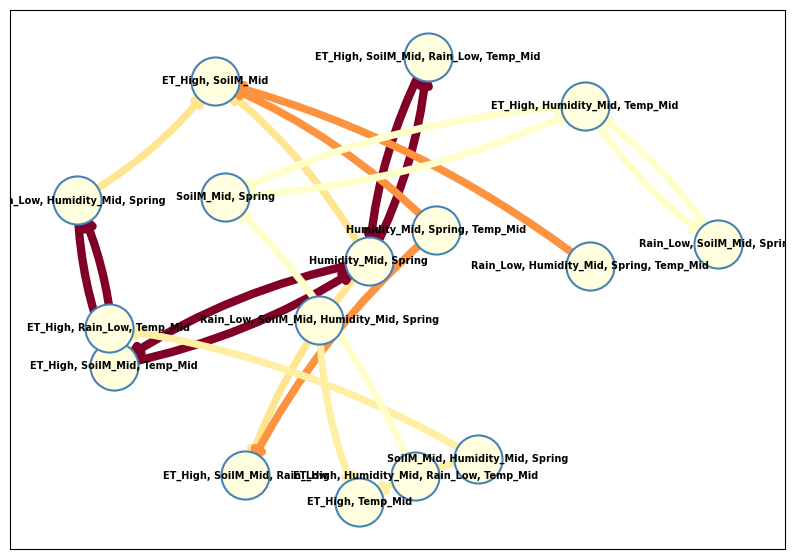

In [156]:
# Network Graph
import networkx as nx

top_rules_net = rules.sort_values('lift', ascending=False).head(20)
G = nx.DiGraph()

for _, row in top_rules_net.iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['lift'])

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42, k=2)
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
max_w = max(edge_weights)

nx.draw_networkx_nodes(G, pos, node_size=1200,
                       node_color='lightyellow', edgecolors='steelblue', linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')
nx.draw_networkx_edges(G, pos,
    width=[2 + 4*(w/max_w) for w in edge_weights],
    edge_color=edge_weights, edge_cmap=plt.cm.YlOrRd,
    arrows=True, arrowsize=15, connectionstyle='arc3,rad=0.1')

sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd,
                            norm=plt.Normalize(min(edge_weights), max(edge_weights)))
sm.set_array([])
plt.colorbar(sm, label='Lift')
plt.title('ARM Network — Top 20 Rules by Lift (AgriSense)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('arm_network.png', dpi=150)
plt.show()

In [ ]:
# Save all rules to CSV
rules_save = rules.copy()
rules_save['antecedents'] = rules_save['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_save['consequents'] = rules_save['consequents'].apply(lambda x: ', '.join(list(x)))
rules_save.to_csv('arm_rules.csv', index=False)
print(f'All {len(rules_save)} rules saved to arm_rules.csv')

In [ ]:
rules_save.head()

# Module 3 part 2

In [113]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [52]:
df = pd.read_csv('/content/merged_smart_water (1).csv')

In [53]:
df["date"] = pd.to_datetime(df.index)

In [54]:
low_soil  = df['v_soilm_0_10cm']    < df['v_soilm_0_10cm'].quantile(0.40)
high_et   = df['evapotranspiration'] > df['evapotranspiration'].quantile(0.60)
no_rain   = df['PRECTOTCORR'] < 1.0

df['irrigation_needed'] = (low_soil & high_et & no_rain).astype(int)

print('Binary label — irrigation_needed')
print(df['irrigation_needed'].value_counts())
print(f'\nPositive class (needs irrigation): {df["irrigation_needed"].mean()*100:.1f}%')

Binary label — irrigation_needed
irrigation_needed
0    1407
1     624
Name: count, dtype: int64

Positive class (needs irrigation): 30.7%


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression

print('All libraries loaded successfully')

All libraries loaded successfully


In [56]:
features = [
    'T2M_MAX', 'T2M_MIN', 'RH2M', 'EVPTRNS',
    'wind_10m_spd_avg', 'skin_temp_avg',
    'soilt_0_10cm', 'soilt_10_40cm',
    'specific_humidity', 'pres_avg'
]

X = df[features]
y = df['irrigation_needed']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} rows')
print(f'Testing set  : {X_test.shape[0]} rows')
print(f'\nClass balance in train: {y_train.mean()*100:.1f}% positive')
print(f'Class balance in test : {y_test.mean()*100:.1f}% positive')

Training set : 1624 rows
Testing set  : 407 rows

Class balance in train: 30.7% positive
Class balance in test : 30.7% positive


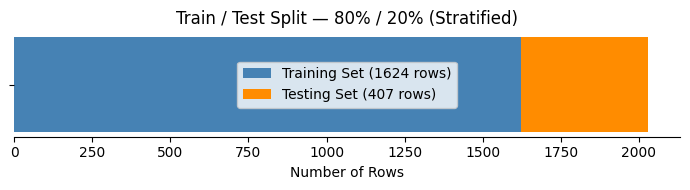

In [57]:
fig, ax = plt.subplots(figsize=(7, 2))

ax.barh([''], [X_train.shape[0]], color='steelblue',
        label=f'Training Set ({X_train.shape[0]} rows)')

ax.barh([''], [X_test.shape[0]], left=[X_train.shape[0]],
        color='darkorange',
        label=f'Testing Set ({X_test.shape[0]} rows)')

ax.set_xlabel('Number of Rows')
ax.set_title('Train / Test Split — 80% / 20% (Stratified)')
ax.legend(loc='center')

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150)
plt.show()

In [58]:
X_train.head()

,T2M_MAX,T2M_MIN,RH2M,EVPTRNS,wind_10m_spd_avg,skin_temp_avg,soilt_0_10cm,soilt_10_40cm,specific_humidity,pres_avg
598,32.22,19.06,41.24,0.00,1.9,32.0,31.4,31.3,0.00798,992.5
1274,30.38,16.82,27.34,0.00,1.1,28.4,28.6,28.4,0.00731,992.8
1076,2.99,-5.42,95.80,0.01,1.4,5.5,8.4,9.0,0.00514,995.7
1700,27.55,13.48,20.96,0.00,1.3,18.4,17.6,19.1,0.00485,999.0
1594,42.26,23.41,14.42,0.00,1.2,34.1,32.3,30.8,0.01065,990.0


In [59]:
mm = MinMaxScaler()
X_train_mnb = np.round(mm.fit_transform(X_train) * 100).astype(int)
X_test_mnb  = np.round(mm.transform(X_test)      * 100).astype(int)

print('Multinomial NB data (first 3 rows):')
print(pd.DataFrame(X_train_mnb[:3], columns=features))

Multinomial NB data (first 3 rows):
   T2M_MAX  T2M_MIN  RH2M  EVPTRNS  wind_10m_spd_avg  skin_temp_avg  \
0       76       79    33        0                26             84   
1       71       73    18        0                 9             74   
2        5        8    95        0                15              7   

   soilt_0_10cm  soilt_10_40cm  specific_humidity  pres_avg  
0            84             90                 48        36  
1            75             79                 42        37  
2            11             12                 23        46  


In [60]:
ss = StandardScaler()
X_train_gnb = ss.fit_transform(X_train)
X_test_gnb  = ss.transform(X_test)

print('Gaussian NB data (first 3 rows):')
print(pd.DataFrame(X_train_gnb[:3], columns=features).round(3))

Gaussian NB data (first 3 rows):
   T2M_MAX  T2M_MIN   RH2M  EVPTRNS  wind_10m_spd_avg  skin_temp_avg  \
0    1.074    1.339 -0.278   -0.526             0.375          1.455   
1    0.880    1.037 -0.919   -0.526            -0.922          1.064   
2   -2.016   -1.956  2.239   -0.515            -0.435         -1.425   

   soilt_0_10cm  soilt_10_40cm  specific_humidity  pres_avg  
0         1.501          1.589              0.972    -0.744  
1         1.173          1.233              0.570    -0.681  
2        -1.192         -1.146             -0.731    -0.076  


In [61]:
X_train_bnb = (X_train_gnb > 0).astype(int)
X_test_bnb  = (X_test_gnb  > 0).astype(int)

print('Bernoulli NB data (first 3 rows):')
print(pd.DataFrame(X_train_bnb[:3], columns=features))

Bernoulli NB data (first 3 rows):
   T2M_MAX  T2M_MIN  RH2M  EVPTRNS  wind_10m_spd_avg  skin_temp_avg  \
0        1        1     0        0                 1              1   
1        1        1     0        0                 0              1   
2        0        0     1        0                 0              0   

   soilt_0_10cm  soilt_10_40cm  specific_humidity  pres_avg  
0             1              1                  1         0  
1             1              1                  1         0  
2             0              0                  0         0  


In [62]:
mnb = MultinomialNB()
mnb.fit(X_train_mnb, y_train)
y_pred_mnb = mnb.predict(X_test_mnb)
acc_mnb = accuracy_score(y_test, y_pred_mnb)
print(f'Multinomial NB Accuracy : {acc_mnb*100:.2f}%')

Multinomial NB Accuracy : 86.24%


In [63]:
gnb = GaussianNB()
gnb.fit(X_train_gnb, y_train)
y_pred_gnb = gnb.predict(X_test_gnb)
acc_gnb = accuracy_score(y_test, y_pred_gnb)
print(f'Gaussian NB Accuracy    : {acc_gnb*100:.2f}%')

Gaussian NB Accuracy    : 88.70%


In [64]:
bnb = BernoulliNB()
bnb.fit(X_train_bnb, y_train)
y_pred_bnb = bnb.predict(X_test_bnb)
acc_bnb = accuracy_score(y_test, y_pred_bnb)
print(f'Bernoulli NB Accuracy   : {acc_bnb*100:.2f}%')

Bernoulli NB Accuracy   : 85.01%


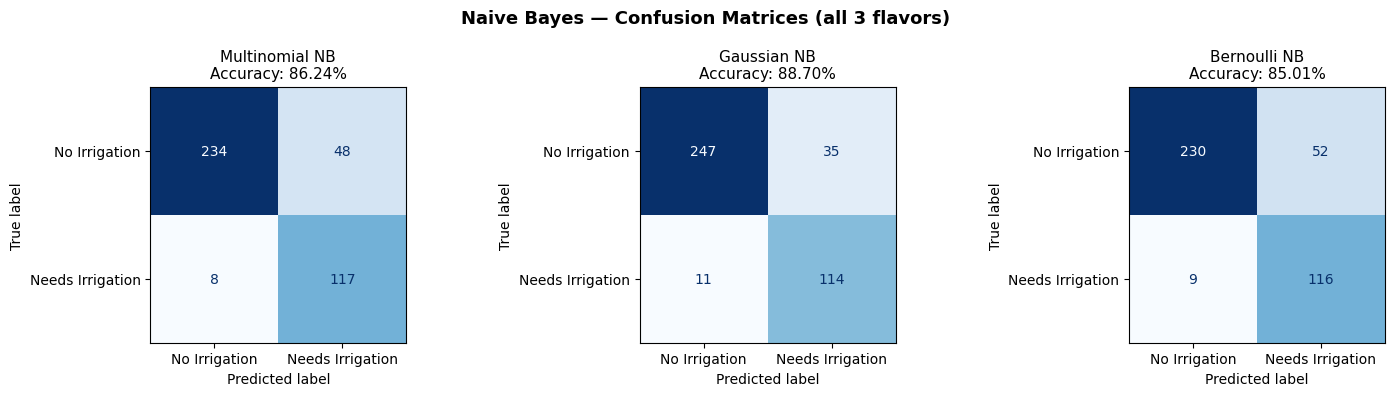

In [65]:
class_names = ['No Irrigation', 'Needs Irrigation']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ('Multinomial NB', y_pred_mnb, acc_mnb),
    ('Gaussian NB',    y_pred_gnb, acc_gnb),
    ('Bernoulli NB',   y_pred_bnb, acc_bnb),
]

for ax, (name, preds, acc) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontsize=11)

plt.suptitle('Naive Bayes — Confusion Matrices (all 3 flavors)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nb_confusion_matrices.png', dpi=150)
plt.show()

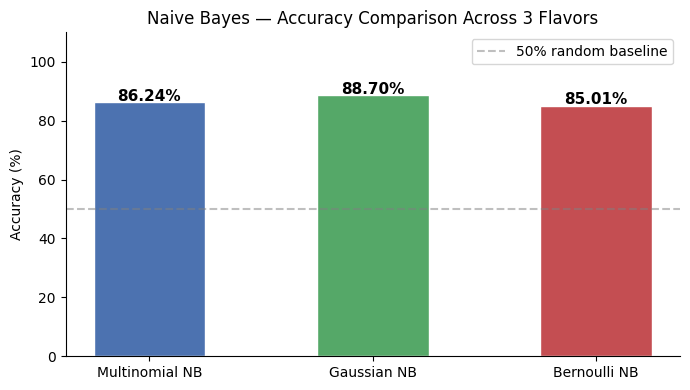

In [66]:
# Accuracy bar chart comparing all 3 NB flavors
names = ['Multinomial NB', 'Gaussian NB', 'Bernoulli NB']
accs  = [acc_mnb * 100, acc_gnb * 100, acc_bnb * 100]
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, accs, color=colors, width=0.5, edgecolor='white')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Naive Bayes — Accuracy Comparison Across 3 Flavors')
ax.axhline(50, color='gray', linestyle='--', alpha=0.5, label='50% random baseline')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('nb_accuracy_comparison.png', dpi=150)
plt.show()

In [67]:
# Full classification reports
print('Multinomial NB')
print(classification_report(y_test, y_pred_mnb, target_names=class_names))

print('Gaussian NB')
print(classification_report(y_test, y_pred_gnb, target_names=class_names))

print('Bernoulli NB')
print(classification_report(y_test, y_pred_bnb, target_names=class_names))

Multinomial NB
                  precision    recall  f1-score   support

   No Irrigation       0.97      0.83      0.89       282
Needs Irrigation       0.71      0.94      0.81       125

        accuracy                           0.86       407
       macro avg       0.84      0.88      0.85       407
    weighted avg       0.89      0.86      0.87       407

Gaussian NB
                  precision    recall  f1-score   support

   No Irrigation       0.96      0.88      0.91       282
Needs Irrigation       0.77      0.91      0.83       125

        accuracy                           0.89       407
       macro avg       0.86      0.89      0.87       407
    weighted avg       0.90      0.89      0.89       407

Bernoulli NB
                  precision    recall  f1-score   support

   No Irrigation       0.96      0.82      0.88       282
Needs Irrigation       0.69      0.93      0.79       125

        accuracy                           0.85       407
       macro avg       0

## Decision Tree

In [68]:
# Manual GINI and Entropy calculation on the training label
counts = y_train.value_counts()
total  = len(y_train)
p0 = counts[0] / total
p1 = counts[1] / total

gini    = 1 - (p0**2 + p1**2)
entropy = -(p0 * np.log2(p0) + p1 * np.log2(p1))

print(f'Class 0 (no irrigation) : {counts[0]} rows  p = {p0:.3f}')
print(f'Class 1 (needs irrigation): {counts[1]} rows  p = {p1:.3f}')
print()
print(f'GINI impurity  = 1 - ({p0:.3f}^2 + {p1:.3f}^2) = {gini:.4f}')
print(f'Entropy        = -({p0:.3f}*log2({p0:.3f}) + {p1:.3f}*log2({p1:.3f})) = {entropy:.4f} bits')
print()
print('A perfectly pure node has GINI = 0 and Entropy = 0.')
print('The tree picks the split that gives the biggest drop in impurity (Information Gain).')

Class 0 (no irrigation) : 1125 rows  p = 0.693
Class 1 (needs irrigation): 499 rows  p = 0.307

GINI impurity  = 1 - (0.693^2 + 0.307^2) = 0.4257
Entropy        = -(0.693*log2(0.693) + 0.307*log2(0.307)) = 0.8900 bits

A perfectly pure node has GINI = 0 and Entropy = 0.
The tree picks the split that gives the biggest drop in impurity (Information Gain).


In [69]:
# Tree 1 -  shallow, GINI, all features  # Root node will be evapotranspiration (the most important split)
dt1 = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt1.fit(X_train, y_train)
y_pred_dt1 = dt1.predict(X_test)
acc_dt1 = accuracy_score(y_test, y_pred_dt1)

print(f'Tree 1 — depth=3, GINI')
print(f'  Root node : {features[dt1.tree_.feature[0]]}')
print(f'  Accuracy  : {acc_dt1*100:.2f}%')
print(f'  Nodes     : {dt1.tree_.node_count}')

Tree 1 — depth=3, GINI
  Root node : soilt_0_10cm
  Accuracy  : 91.65%
  Nodes     : 15


In [70]:
# Tree 2 : medium depth, Entropy criterion # Same features but entropy changes which splits are chosen
dt2 = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
dt2.fit(X_train, y_train)
y_pred_dt2 = dt2.predict(X_test)
acc_dt2 = accuracy_score(y_test, y_pred_dt2)

print(f'Tree 2 — depth=5, Entropy')
print(f'  Root node : {features[dt2.tree_.feature[0]]}')
print(f'  Accuracy  : {acc_dt2*100:.2f}%')
print(f'  Nodes     : {dt2.tree_.node_count}')

Tree 2 — depth=5, Entropy
  Root node : soilt_0_10cm
  Accuracy  : 92.87%
  Nodes     : 53


In [71]:
# Tree 3 : remove evapotranspiration so the tree must find a different root # This forces a completely different tree structure
features_no_et = [f for f in features if f != 'evapotranspiration']

X_train_t3 = X_train[features_no_et]
X_test_t3  = X_test[features_no_et]

dt3 = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
dt3.fit(X_train_t3, y_train)
y_pred_dt3 = dt3.predict(X_test_t3)
acc_dt3 = accuracy_score(y_test, y_pred_dt3)

print(f'Tree 3 — depth=5, GINI, no ET feature')
print(f'  Root node : {features_no_et[dt3.tree_.feature[0]]}')
print(f'  Accuracy  : {acc_dt3*100:.2f}%')
print(f'  Nodes     : {dt3.tree_.node_count}')

Tree 3 — depth=5, GINI, no ET feature
  Root node : soilt_0_10cm
  Accuracy  : 92.38%
  Nodes     : 55


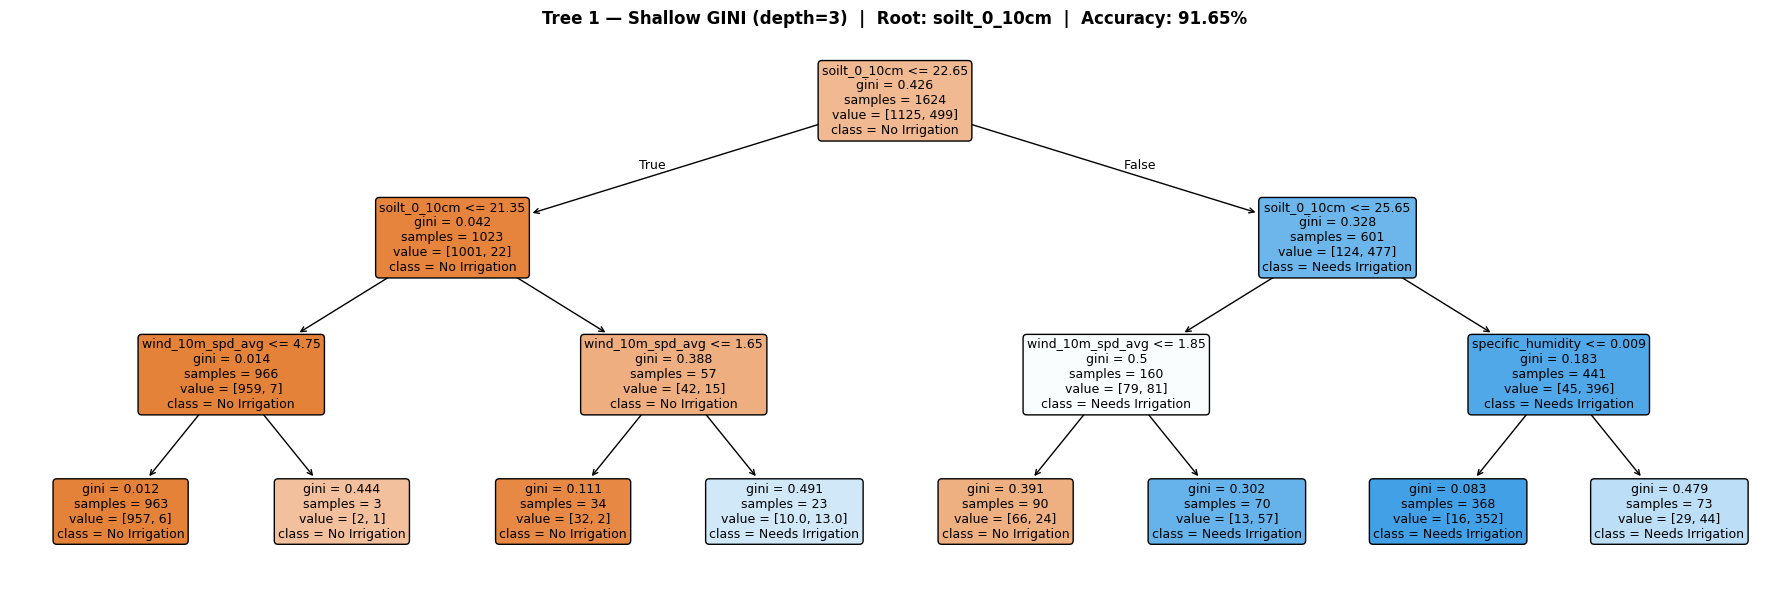

In [72]:
# Tree 1 plot
fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(dt1, feature_names=features, class_names=['No Irrigation', 'Needs Irrigation'],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title(f'Tree 1 — Shallow GINI (depth=3)  |  Root: {features[dt1.tree_.feature[0]]}  |  Accuracy: {acc_dt1*100:.2f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_tree1.png', dpi=130)
plt.show()

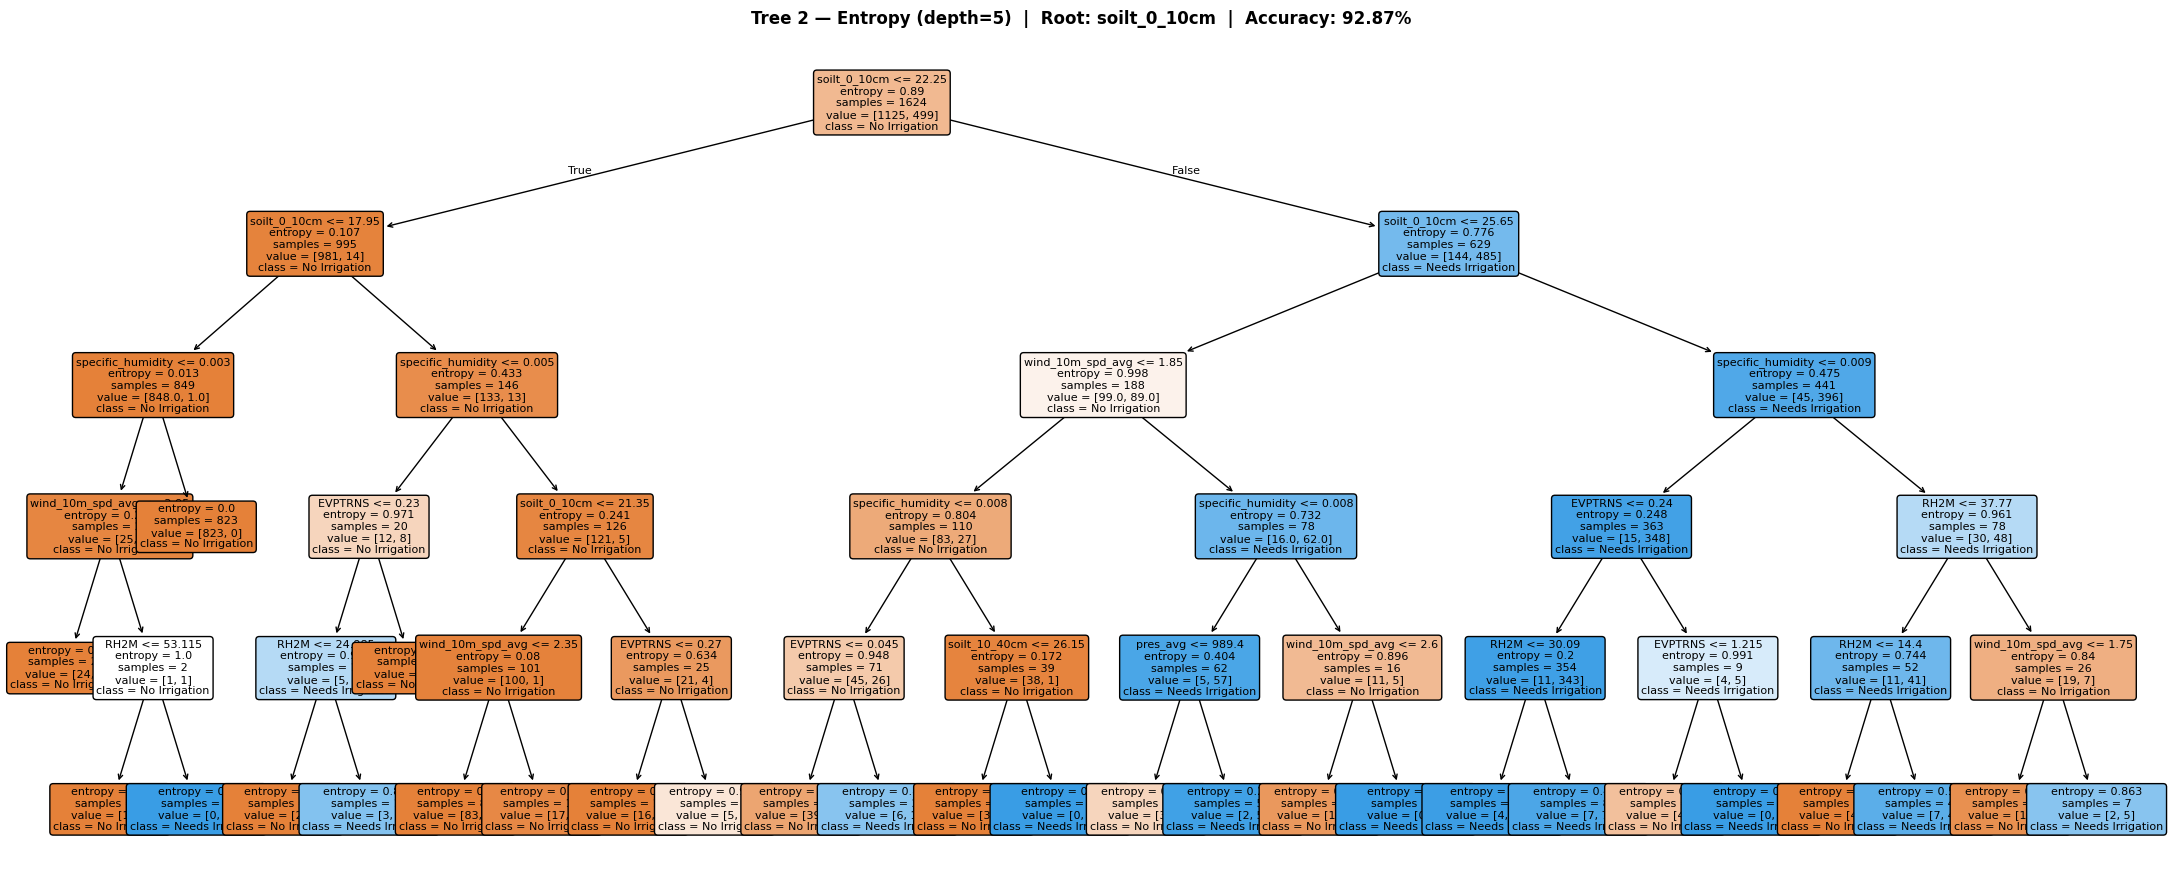

In [73]:
# Tree 2 plot
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt2, feature_names=features, class_names=['No Irrigation', 'Needs Irrigation'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title(f'Tree 2 — Entropy (depth=5)  |  Root: {features[dt2.tree_.feature[0]]}  |  Accuracy: {acc_dt2*100:.2f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_tree2.png', dpi=130)
plt.show()

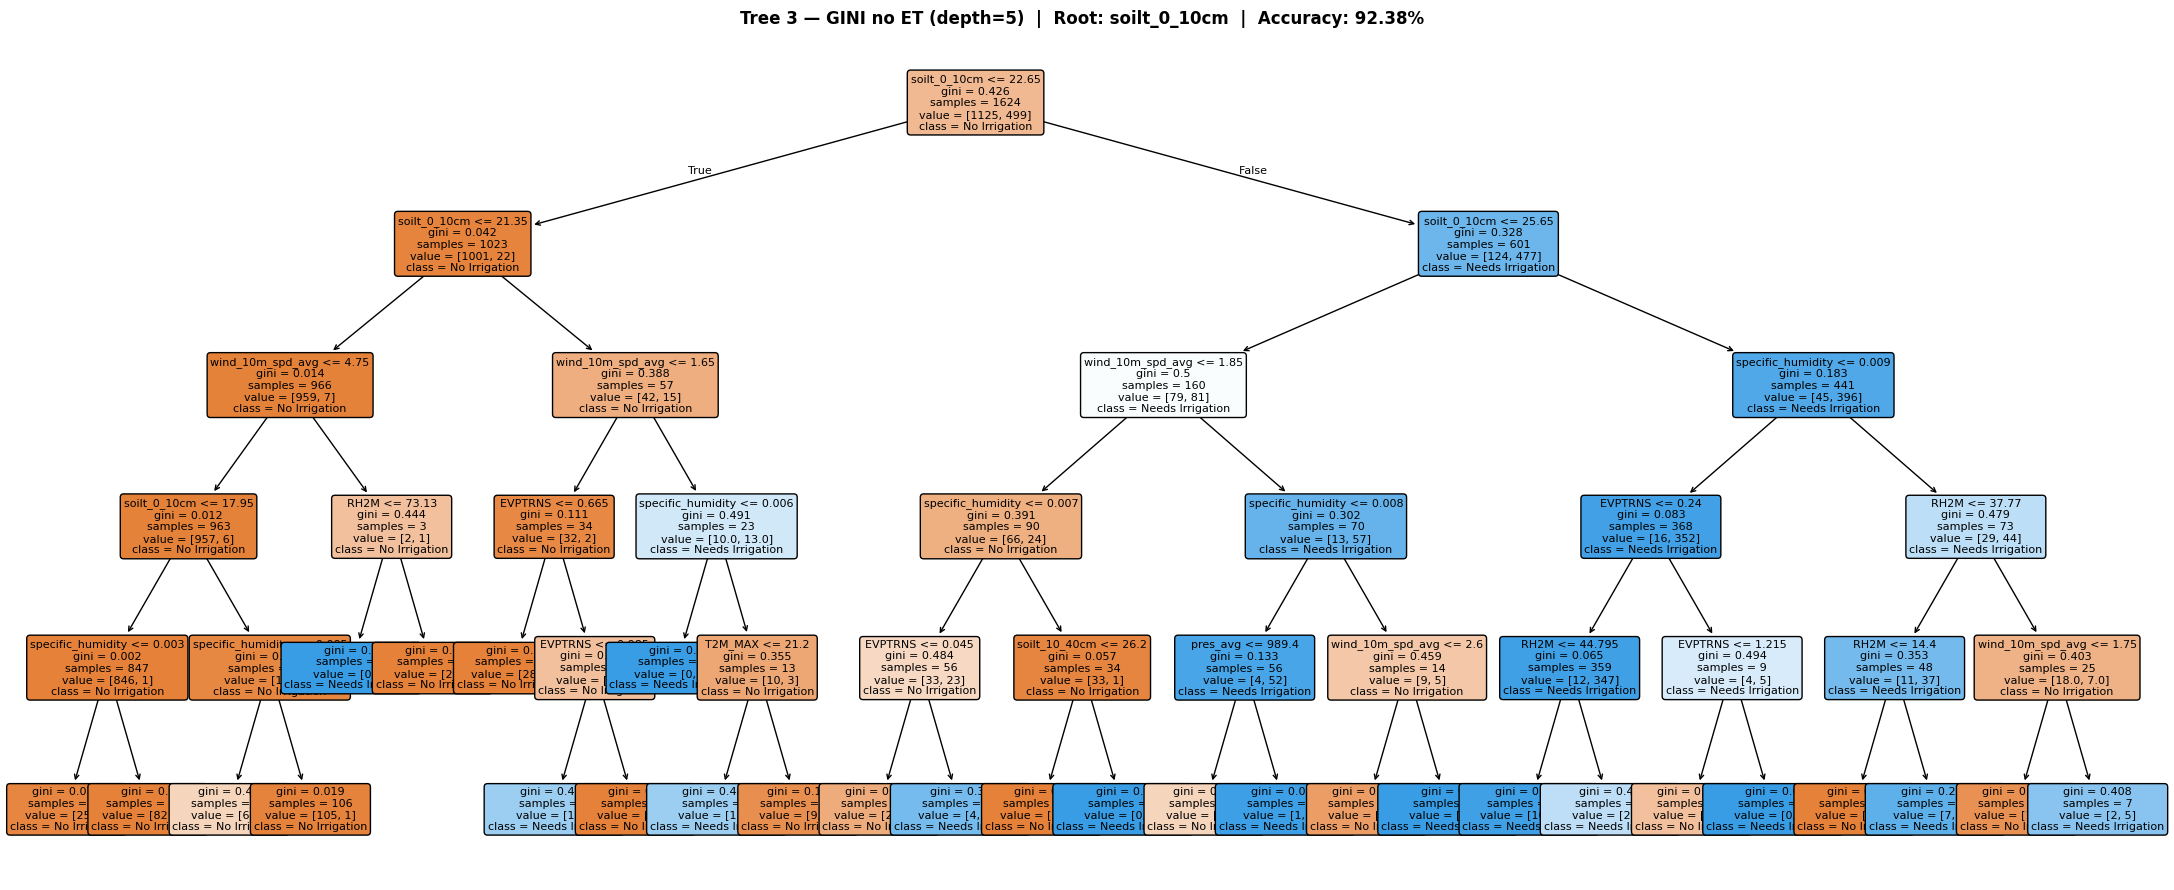

In [74]:
# Tree 3 plot
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt3, feature_names=features_no_et, class_names=['No Irrigation', 'Needs Irrigation'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title(f'Tree 3 — GINI no ET (depth=5)  |  Root: {features_no_et[dt3.tree_.feature[0]]}  |  Accuracy: {acc_dt3*100:.2f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_tree3.png', dpi=130)
plt.show()

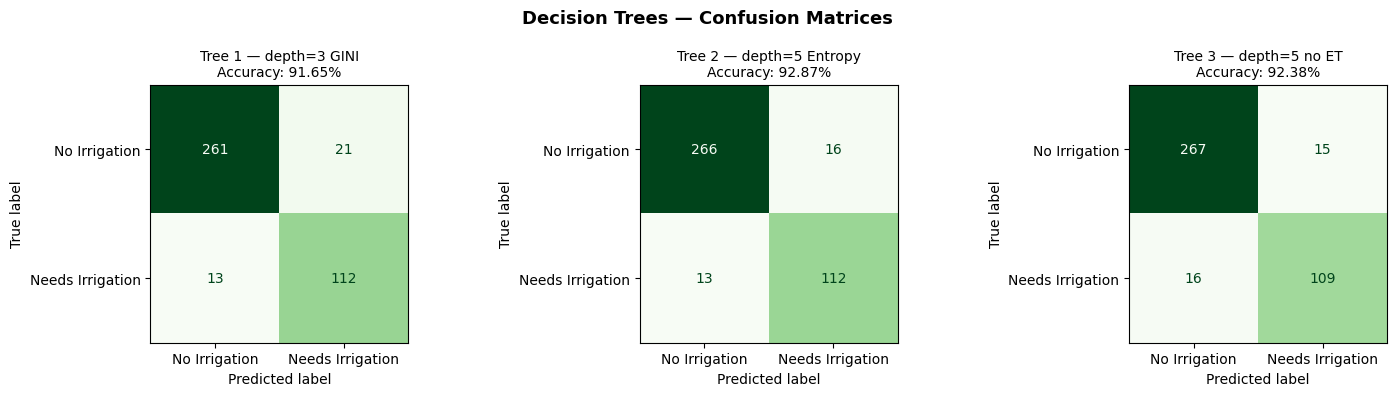

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

dt_models = [
    ('Tree 1 — depth=3 GINI',    y_pred_dt1, acc_dt1),
    ('Tree 2 — depth=5 Entropy', y_pred_dt2, acc_dt2),
    ('Tree 3 — depth=5 no ET',   y_pred_dt3, acc_dt3),
]

for ax, (name, preds, acc) in zip(axes, dt_models):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontsize=10)

plt.suptitle('Decision Trees — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_confusion_matrices.png', dpi=150)
plt.show()

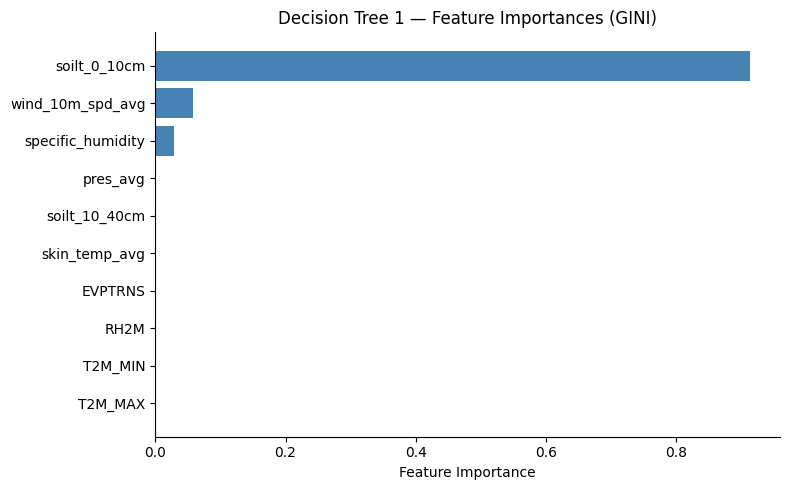

In [76]:
# Feature importance from Tree 1 (best interpretable tree)
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': dt1.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Decision Tree 1 — Feature Importances (GINI)')
sns.despine()
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150)
plt.show()

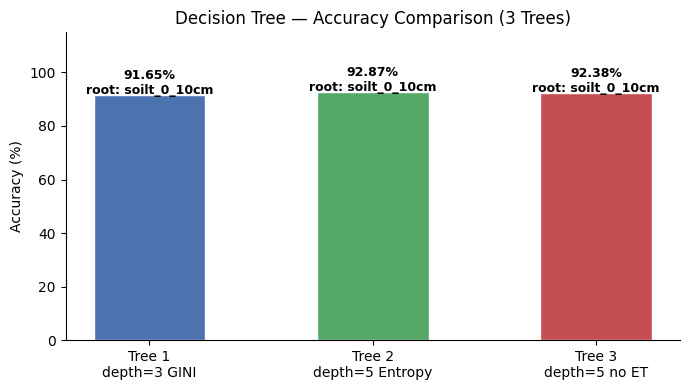

In [77]:
# Accuracy comparison across 3 trees
tree_names = ['Tree 1\ndepth=3 GINI', 'Tree 2\ndepth=5 Entropy', 'Tree 3\ndepth=5 no ET']
tree_accs  = [acc_dt1*100, acc_dt2*100, acc_dt3*100]
tree_roots = [features[dt1.tree_.feature[0]],
              features[dt2.tree_.feature[0]],
              features_no_et[dt3.tree_.feature[0]]]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(tree_names, tree_accs, color=['#4C72B0','#55A868','#C44E52'], width=0.5, edgecolor='white')

for bar, acc, root in zip(bars, tree_accs, tree_roots):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%\nroot: {root}', ha='center', fontsize=9, fontweight='bold')

ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Decision Tree — Accuracy Comparison (3 Trees)')
sns.despine()
plt.tight_layout()
plt.savefig('dt_accuracy_comparison.png', dpi=150)
plt.show()

## Logistic Regression

In [78]:
# Scale features for logistic regression
lr_scaler = StandardScaler()
X_train_lr = lr_scaler.fit_transform(X_train)
X_test_lr  = lr_scaler.transform(X_test)

# Train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_lr, y_train)

y_pred_lr = lr.predict(X_test_lr)
acc_lr    = accuracy_score(y_test, y_pred_lr)

print(f'Logistic Regression Accuracy: {acc_lr*100:.2f}%')
print()
print(classification_report(y_test, y_pred_lr, target_names=class_names))

Logistic Regression Accuracy: 92.38%

                  precision    recall  f1-score   support

   No Irrigation       0.96      0.93      0.94       282
Needs Irrigation       0.85      0.91      0.88       125

        accuracy                           0.92       407
       macro avg       0.91      0.92      0.91       407
    weighted avg       0.93      0.92      0.92       407



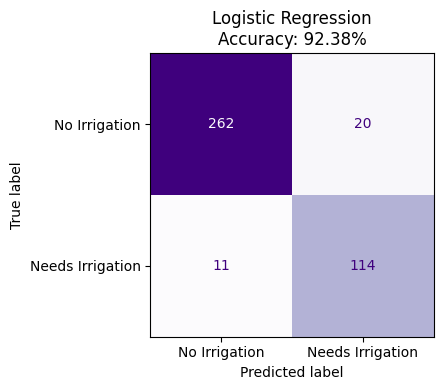

In [79]:
fig, ax = plt.subplots(figsize=(5, 4))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp  = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title(f'Logistic Regression\nAccuracy: {acc_lr*100:.2f}%', fontsize=12)
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150)
plt.show()

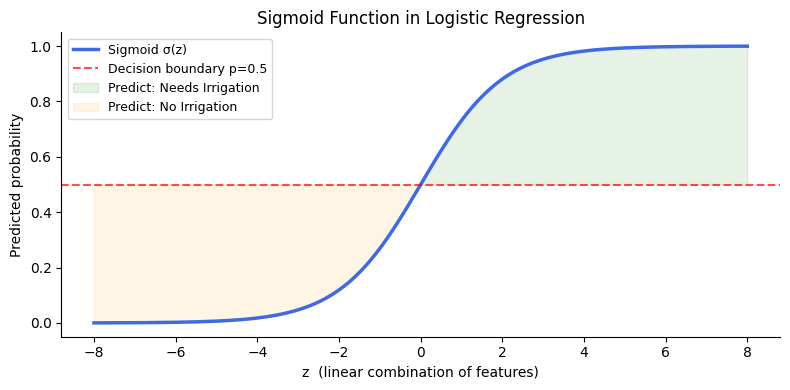

In [80]:
# Plot the sigmoid function used inside logistic regression
z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z, sigmoid, color='royalblue', linewidth=2.5, label='Sigmoid σ(z)')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Decision boundary p=0.5')
ax.fill_between(z, sigmoid, 0.5, where=(sigmoid > 0.5), alpha=0.1, color='green',  label='Predict: Needs Irrigation')
ax.fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5), alpha=0.1, color='orange', label='Predict: No Irrigation')
ax.set_xlabel('z  (linear combination of features)')
ax.set_ylabel('Predicted probability')
ax.set_title('Sigmoid Function in Logistic Regression')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('lr_sigmoid.png', dpi=150)
plt.show()

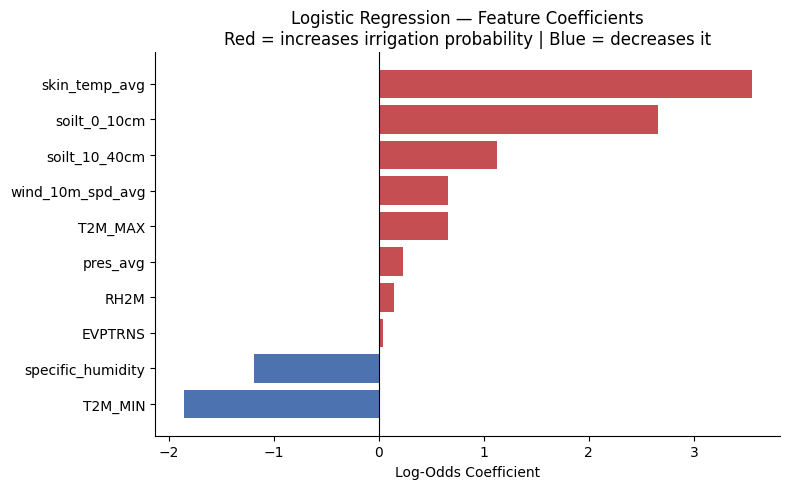

In [81]:
coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient')

colors_coef = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Log-Odds Coefficient')
ax.set_title('Logistic Regression — Feature Coefficients\nRed = increases irrigation probability | Blue = decreases it')
sns.despine()
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150)
plt.show()

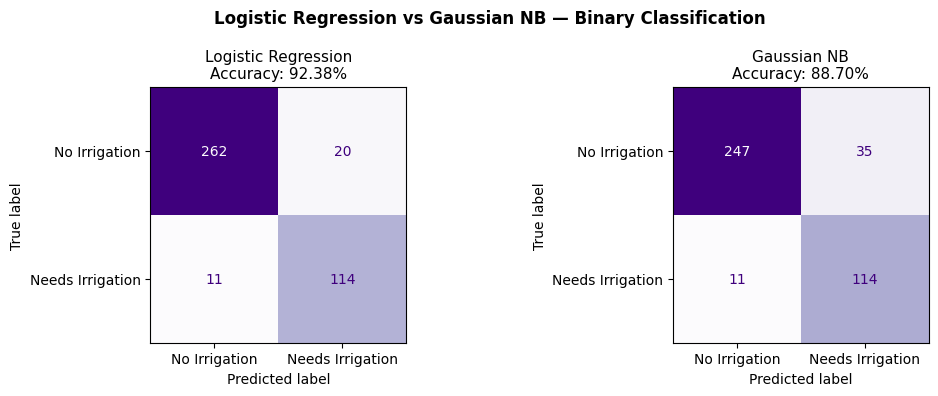

In [82]:
# Compare logistic regression and Gaussian NB side by side (both binary classifiers)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, preds, acc) in zip(axes, [
    ('Logistic Regression', y_pred_lr,  acc_lr),
    ('Gaussian NB',         y_pred_gnb, acc_gnb)
]):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
        ax=ax, colorbar=False, cmap='Purples'
    )
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontsize=11)

plt.suptitle('Logistic Regression vs Gaussian NB — Binary Classification', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_vs_gnb.png', dpi=150)
plt.show()

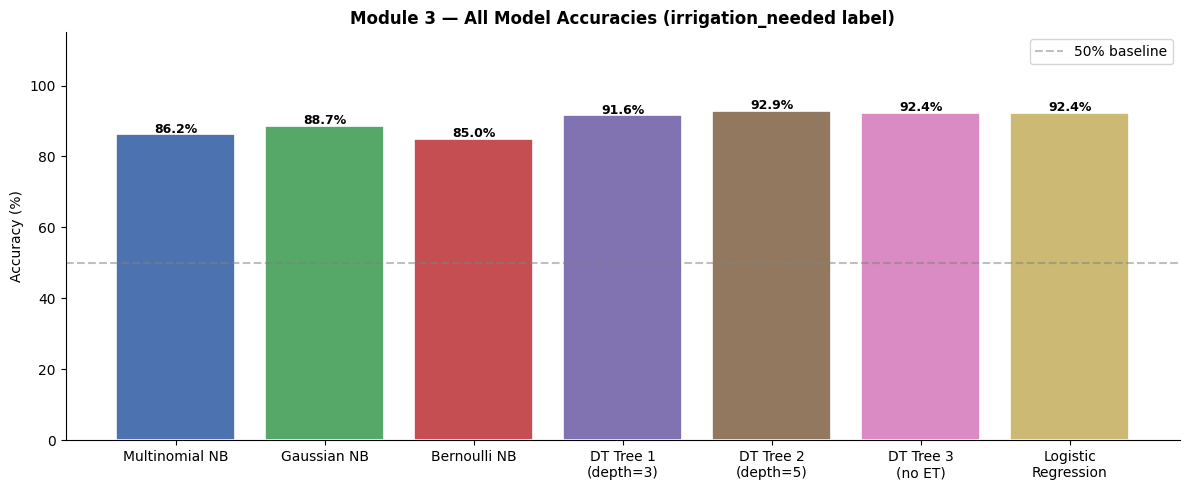


Summary:
  Multinomial NB                : 86.24%
  Gaussian NB                   : 88.70%
  Bernoulli NB                  : 85.01%
  DT Tree 1 (depth=3)           : 91.65%
  DT Tree 2 (depth=5)           : 92.87%
  DT Tree 3 (no ET)             : 92.38%
  Logistic Regression           : 92.38%


In [83]:
2# Final accuracy summary bar chart for all models
all_names = [
    'Multinomial NB', 'Gaussian NB', 'Bernoulli NB',
    'DT Tree 1\n(depth=3)', 'DT Tree 2\n(depth=5)', 'DT Tree 3\n(no ET)',
    'Logistic\nRegression'
]
all_accs = [
    acc_mnb*100, acc_gnb*100, acc_bnb*100,
    acc_dt1*100, acc_dt2*100, acc_dt3*100,
    acc_lr*100
]
all_colors = ['#4C72B0','#55A868','#C44E52',
              '#8172B2','#937860','#DA8BC3',
              '#CCB974']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(all_names, all_accs, color=all_colors, edgecolor='white', linewidth=1.2)

for bar, acc in zip(bars, all_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{acc:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Module 3 — All Model Accuracies (irrigation_needed label)', fontsize=12, fontweight='bold')
ax.axhline(50, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('all_models_accuracy.png', dpi=150)
plt.show()

print('\nSummary:')
for n, a in zip(all_names, all_accs):
    print(f'  {n.replace(chr(10)," "):30s}: {a:.2f}%')

In [84]:
print('Module 3 complete!')
print('Files saved:')
for f in ['train_test_split.png', 'nb_confusion_matrices.png', 'nb_accuracy_comparison.png',
          'dt_tree1.png', 'dt_tree2.png', 'dt_tree3.png',
          'dt_confusion_matrices.png', 'dt_feature_importance.png', 'dt_accuracy_comparison.png',
          'lr_confusion_matrix.png', 'lr_sigmoid.png', 'lr_coefficients.png',
          'lr_vs_gnb.png', 'all_models_accuracy.png']:
    print(f'  {f}')

Module 3 complete!
Files saved:
  train_test_split.png
  nb_confusion_matrices.png
  nb_accuracy_comparison.png
  dt_tree1.png
  dt_tree2.png
  dt_tree3.png
  dt_confusion_matrices.png
  dt_feature_importance.png
  dt_accuracy_comparison.png
  lr_confusion_matrix.png
  lr_sigmoid.png
  lr_coefficients.png
  lr_vs_gnb.png
  all_models_accuracy.png


In [85]:
print(df[features].head())

   T2M_MAX  T2M_MIN   RH2M  EVPTRNS  wind_10m_spd_avg  skin_temp_avg  \
0    13.60     3.05  65.03     0.48               1.3            6.7   
1    15.37     2.89  63.18     0.64               1.0            6.3   
2    17.73     4.78  51.74     0.70               0.8            9.0   
3    14.17     3.98  48.59     0.53               1.7            9.1   
4    11.72     2.61  51.75     0.48               2.1            7.2   

   soilt_0_10cm  soilt_10_40cm  specific_humidity  pres_avg  
0           8.0            7.7            0.00537     999.8  
1           7.4            7.7            0.00600    1000.1  
2           8.4            8.4            0.00543    1004.0  
3           9.9            9.1            0.00539    1007.2  
4           8.4            8.7            0.00544    1011.3  


In [86]:
print(pd.DataFrame(X_train_mnb[:5], columns=features))

   T2M_MAX  T2M_MIN  RH2M  EVPTRNS  wind_10m_spd_avg  skin_temp_avg  \
0       76       79    33        0                26             84   
1       71       73    18        0                 9             74   
2        5        8    95        0                15              7   
3       64       63    10        0                13             45   
4      100       92     3        0                11             90   

   soilt_0_10cm  soilt_10_40cm  specific_humidity  pres_avg  
0            84             90                 48        36  
1            75             79                 42        37  
2            11             12                 23        46  
3            40             47                 21        57  
4            87             88                 72        27  


In [87]:
print(pd.DataFrame(X_train_gnb[:5], columns=features).round(3))

   T2M_MAX  T2M_MIN   RH2M  EVPTRNS  wind_10m_spd_avg  skin_temp_avg  \
0    1.074    1.339 -0.278   -0.526             0.375          1.455   
1    0.880    1.037 -0.919   -0.526            -0.922          1.064   
2   -2.016   -1.956  2.239   -0.515            -0.435         -1.425   
3    0.580    0.588 -1.213   -0.526            -0.598         -0.023   
4    2.136    1.924 -1.515   -0.526            -0.760          1.683   

   soilt_0_10cm  soilt_10_40cm  specific_humidity  pres_avg  
0         1.501          1.589              0.972    -0.744  
1         1.173          1.233              0.570    -0.681  
2        -1.192         -1.146             -0.731    -0.076  
3        -0.115          0.093             -0.905     0.613  
4         1.606          1.527              2.572    -1.266  


In [88]:
print(pd.DataFrame(X_train_bnb[:5], columns=features))

   T2M_MAX  T2M_MIN  RH2M  EVPTRNS  wind_10m_spd_avg  skin_temp_avg  \
0        1        1     0        0                 1              1   
1        1        1     0        0                 0              1   
2        0        0     1        0                 0              0   
3        1        1     0        0                 0              0   
4        1        1     0        0                 0              1   

   soilt_0_10cm  soilt_10_40cm  specific_humidity  pres_avg  
0             1              1                  1         0  
1             1              1                  1         0  
2             0              0                  0         0  
3             0              1                  0         1  
4             1              1                  1         0  


In [89]:
print(pd.DataFrame(X_train_lr[:5], columns=features).round(3))

   T2M_MAX  T2M_MIN   RH2M  EVPTRNS  wind_10m_spd_avg  skin_temp_avg  \
0    1.074    1.339 -0.278   -0.526             0.375          1.455   
1    0.880    1.037 -0.919   -0.526            -0.922          1.064   
2   -2.016   -1.956  2.239   -0.515            -0.435         -1.425   
3    0.580    0.588 -1.213   -0.526            -0.598         -0.023   
4    2.136    1.924 -1.515   -0.526            -0.760          1.683   

   soilt_0_10cm  soilt_10_40cm  specific_humidity  pres_avg  
0         1.501          1.589              0.972    -0.744  
1         1.173          1.233              0.570    -0.681  
2        -1.192         -1.146             -0.731    -0.076  
3        -0.115          0.093             -0.905     0.613  
4         1.606          1.527              2.572    -1.266  


# Module 4

In [90]:
# Polynomial kernel example: cast a 2D point into higher dimensions
# Using polynomial kernel with r=1, d=2
# For point x = (x1, x2), the polynomial kernel K(x,x) = (x·x + r)^d
# With r=1, d=2: K(xi, xj) = (xi·xj + 1)^2
# Implicit feature map for x=(x1,x2): phi(x) = [x1^2, x2^2, sqrt(2)*x1*x2, sqrt(2)*x1, sqrt(2)*x2, 1]

x = np.array([2.0, 3.0])  # example 2D point
r, d = 1, 2

# Compute polynomial feature map (r=1, d=2)
phi = np.array([
    x[0]**2,
    x[1]**2,
    np.sqrt(2) * x[0] * x[1],
    np.sqrt(2) * x[0],
    np.sqrt(2) * x[1],
    1.0
])

print('Polynomial Kernel Example — r=1, d=2')
print(f'Original 2D point x = {x}')
print(f'Feature map phi(x) = {phi.round(3)}')
print(f'Mapped to {len(phi)} dimensions (from 2)')
print()

# Verify: dot product of phi with itself should equal kernel value
kernel_val = (np.dot(x, x) + r) ** d
dot_product = np.dot(phi, phi)
print(f'Kernel K(x,x) = (x·x + r)^d = ({np.dot(x,x)} + 1)^2 = {kernel_val}')
print(f'phi(x)·phi(x) = {dot_product:.3f}  ← same value, no explicit computation needed!')
print()
print('This is the kernel trick — compute similarity in high dimensions')
print('without ever explicitly computing the high-dimensional coordinates.')

Polynomial Kernel Example — r=1, d=2
Original 2D point x = [2. 3.]
Feature map phi(x) = [4.    9.    8.485 2.828 4.243 1.   ]
Mapped to 6 dimensions (from 2)

Kernel K(x,x) = (x·x + r)^d = (13.0 + 1)^2 = 196.0
phi(x)·phi(x) = 196.000  ← same value, no explicit computation needed!

This is the kernel trick — compute similarity in high dimensions
without ever explicitly computing the high-dimensional coordinates.


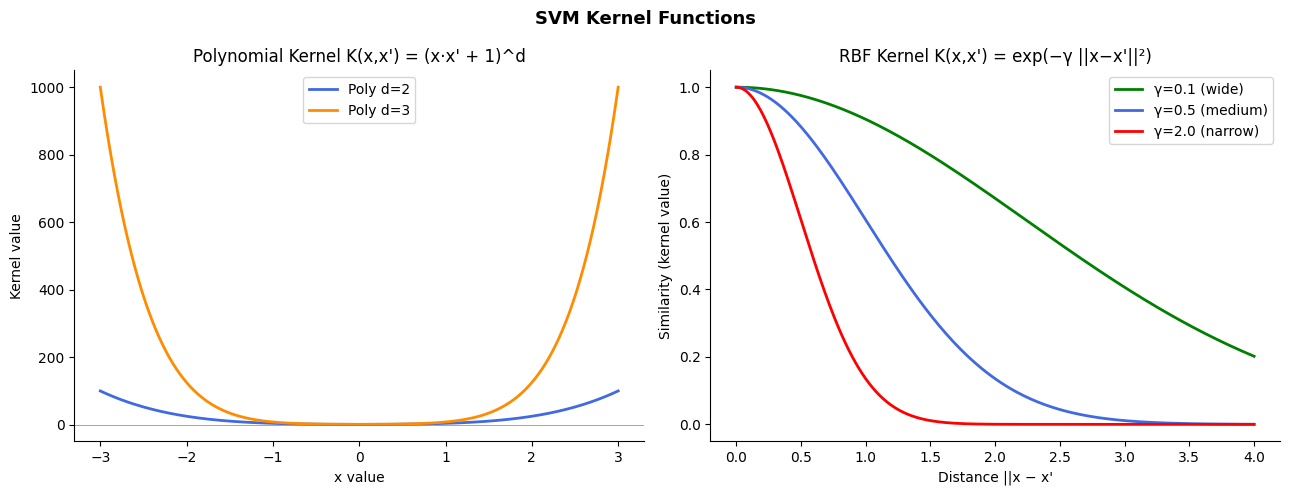

Saved: svm_kernel_functions.png


In [91]:
# Visualise kernel functions
z = np.linspace(-3, 3, 300)

# Polynomial kernel K(x, x') = (x*x' + 1)^d evaluated along diagonal
poly2 = (z * z + 1) ** 2
poly3 = (z * z + 1) ** 3

# RBF kernel K(x, x') = exp(-gamma * ||x - x'||^2), along distance axis
distance = np.linspace(0, 4, 300)
rbf_g1  = np.exp(-0.5 * distance**2)
rbf_g01 = np.exp(-0.1 * distance**2)
rbf_g2  = np.exp(-2.0 * distance**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Polynomial
axes[0].plot(z, poly2, color='royalblue', linewidth=2, label='Poly d=2')
axes[0].plot(z, poly3, color='darkorange', linewidth=2, label='Poly d=3')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].set_title('Polynomial Kernel K(x,x\') = (x·x\' + 1)^d')
axes[0].set_xlabel('x value'); axes[0].set_ylabel('Kernel value')
axes[0].legend(); sns.despine(ax=axes[0])

# RBF
axes[1].plot(distance, rbf_g01, color='green',     linewidth=2, label='γ=0.1 (wide)')
axes[1].plot(distance, rbf_g1,  color='royalblue', linewidth=2, label='γ=0.5 (medium)')
axes[1].plot(distance, rbf_g2,  color='red',       linewidth=2, label='γ=2.0 (narrow)')
axes[1].set_title('RBF Kernel K(x,x\') = exp(−γ ||x−x\'||²)')
axes[1].set_xlabel('Distance ||x − x\'')
axes[1].set_ylabel('Similarity (kernel value)')
axes[1].legend(); sns.despine(ax=axes[1])

plt.suptitle('SVM Kernel Functions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_kernel_functions.png', dpi=150)
plt.show()
print('Saved: svm_kernel_functions.png')

In [94]:
df = pd.read_csv('/content/merged_smart_water (1).csv', parse_dates=['date'])

# Recreate binary label (same as Module 3)
low_soil = df['v_soilm_0_10cm']    < df['v_soilm_0_10cm'].quantile(0.40)
high_et  = df['evapotranspiration'] > df['evapotranspiration'].quantile(0.60)
no_rain  = df['PRECTOTCORR'] < 1.0
df['irrigation_needed'] = (low_soil & high_et & no_rain).astype(int)

# Same clean features (no leaky columns)
features = [
    'T2M_MAX', 'T2M_MIN', 'RH2M', 'EVPTRNS',
    'wind_10m_spd_avg', 'skin_temp_avg',
    'soilt_0_10cm', 'soilt_10_40cm',
    'specific_humidity', 'pres_avg'
]

X = df[features]
y = df['irrigation_needed']

# Same 80/20 stratified split as Module 3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale for SVM (required)
svm_scaler = StandardScaler()
X_train_svm = svm_scaler.fit_transform(X_train)
X_test_svm  = svm_scaler.transform(X_test)

print(f'Dataset loaded — shape: {df.shape}')
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'Positive class: {y.mean()*100:.1f}%')

Dataset loaded — shape: (2031, 39)
Train: 1624 rows | Test: 407 rows
Positive class: 30.7%


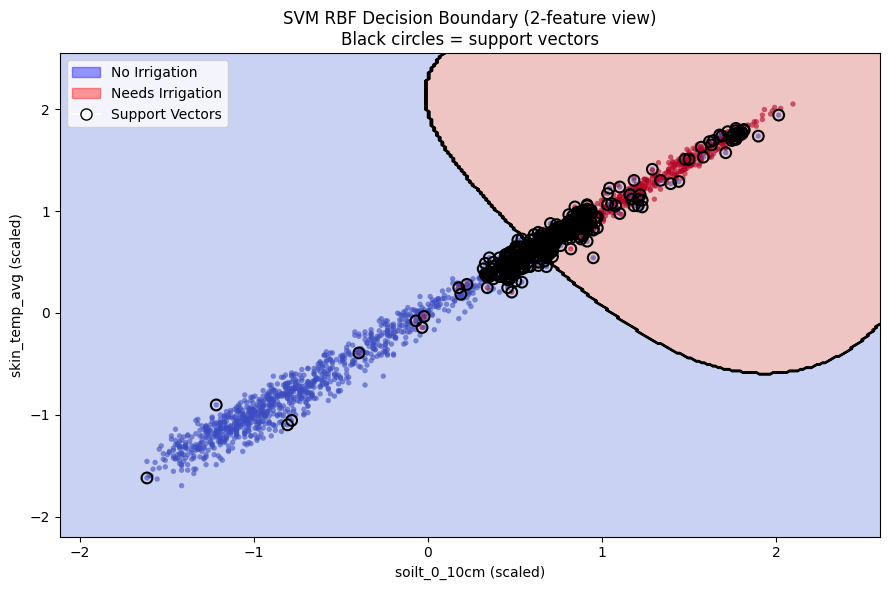

Saved: svm_decision_boundary.png


In [95]:
# Visualise SVM decision boundary concept using 2 features
from sklearn.svm import SVC
import matplotlib.patches as mpatches

# Use 2 features for visualization: soilt_0_10cm and skin_temp_avg
feat_2d = ['soilt_0_10cm', 'skin_temp_avg']
X_2d = df[feat_2d]
y_2d = df['irrigation_needed']

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)
sc2 = StandardScaler()
X_tr2s = sc2.fit_transform(X_tr2)
X_te2s  = sc2.transform(X_te2)

# Fit RBF SVM on 2D for visualization
svm_vis = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_vis.fit(X_tr2s, y_tr2)

# Create mesh
xx, yy = np.meshgrid(
    np.linspace(X_tr2s[:,0].min()-0.5, X_tr2s[:,0].max()+0.5, 300),
    np.linspace(X_tr2s[:,1].min()-0.5, X_tr2s[:,1].max()+0.5, 300)
)
Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
ax.contour(xx, yy, Z, colors='black', linewidths=1.0)
scatter = ax.scatter(
    X_tr2s[:, 0], X_tr2s[:, 1],
    c=y_tr2, cmap='coolwarm', s=15, alpha=0.6, edgecolors='none'
)
# Mark support vectors
sv = svm_vis.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], s=60, facecolors='none',
           edgecolors='black', linewidths=1.5, label='Support Vectors')
ax.set_xlabel('soilt_0_10cm (scaled)'); ax.set_ylabel('skin_temp_avg (scaled)')
ax.set_title('SVM RBF Decision Boundary (2-feature view)\nBlack circles = support vectors')
p0 = mpatches.Patch(color='blue', alpha=0.4, label='No Irrigation')
p1 = mpatches.Patch(color='red',  alpha=0.4, label='Needs Irrigation')
ax.legend(handles=[p0, p1, plt.Line2D([0],[0], marker='o', color='w',
          markeredgecolor='black', markersize=8, label='Support Vectors')])
plt.tight_layout()
plt.savefig('svm_decision_boundary.png', dpi=150)
plt.show()
print('Saved: svm_decision_boundary.png')

In [96]:
print('SVM Data Preparation Summary')
print('='*45)
print(f'Features used : {features}')
print(f'Label         : irrigation_needed (binary 0/1)')
print(f'Train rows    : {X_train_svm.shape[0]}')
print(f'Test rows     : {X_test_svm.shape[0]}')
print(f'Scaling       : StandardScaler (required for SVM)')
print()
print('Before scaling — first 3 rows:')
print(X_train.head(3).to_string())
print()
print('After StandardScaler — first 3 rows:')
print(pd.DataFrame(X_train_svm[:3], columns=features).round(3).to_string())

SVM Data Preparation Summary
Features used : ['T2M_MAX', 'T2M_MIN', 'RH2M', 'EVPTRNS', 'wind_10m_spd_avg', 'skin_temp_avg', 'soilt_0_10cm', 'soilt_10_40cm', 'specific_humidity', 'pres_avg']
Label         : irrigation_needed (binary 0/1)
Train rows    : 1624
Test rows     : 407
Scaling       : StandardScaler (required for SVM)

Before scaling — first 3 rows:
      T2M_MAX  T2M_MIN   RH2M  EVPTRNS  wind_10m_spd_avg  skin_temp_avg  soilt_0_10cm  soilt_10_40cm  specific_humidity  pres_avg
598     32.22    19.06  41.24     0.00               1.9           32.0          31.4           31.3            0.00798     992.5
1274    30.38    16.82  27.34     0.00               1.1           28.4          28.6           28.4            0.00731     992.8
1076     2.99    -5.42  95.80     0.01               1.4            5.5           8.4            9.0            0.00514     995.7

After StandardScaler — first 3 rows:
   T2M_MAX  T2M_MIN   RH2M  EVPTRNS  wind_10m_spd_avg  skin_temp_avg  soilt_0_10cm

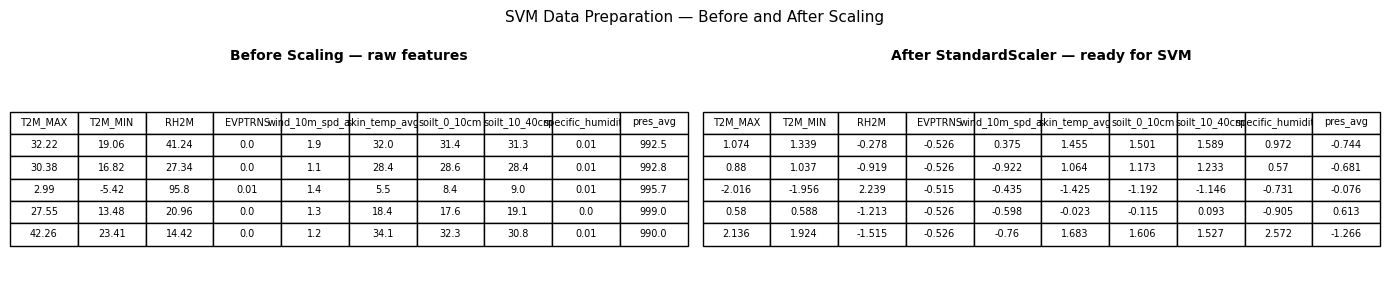

Saved: svm_before_after_data.png


In [97]:
# Save before/after screenshots
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

axes[0].axis('off')
tbl0 = axes[0].table(
    cellText=X_train.head(5).round(2).values.tolist(),
    colLabels=features, loc='center', cellLoc='center'
)
tbl0.auto_set_font_size(False); tbl0.set_fontsize(7); tbl0.scale(1, 1.4)
axes[0].set_title('Before Scaling — raw features', fontsize=10, fontweight='bold')

axes[1].axis('off')
tbl1 = axes[1].table(
    cellText=pd.DataFrame(X_train_svm[:5], columns=features).round(3).values.tolist(),
    colLabels=features, loc='center', cellLoc='center'
)
tbl1.auto_set_font_size(False); tbl1.set_fontsize(7); tbl1.scale(1, 1.4)
axes[1].set_title('After StandardScaler — ready for SVM', fontsize=10, fontweight='bold')

plt.suptitle('SVM Data Preparation — Before and After Scaling', fontsize=11)
plt.tight_layout()
plt.savefig('svm_before_after_data.png', dpi=150)
plt.show()
print('Saved: svm_before_after_data.png')

In [98]:
# Cost values to try for each kernel
costs = [0.01, 0.1, 1, 10, 100]
kernels = ['linear', 'poly', 'rbf']

tuning_results = {}

for kernel in kernels:
    tuning_results[kernel] = {}
    for C in costs:
        svm = SVC(kernel=kernel, C=C, degree=3, gamma='scale', random_state=42)
        svm.fit(X_train_svm, y_train)
        acc = accuracy_score(y_test, svm.predict(X_test_svm))
        tuning_results[kernel][C] = acc
    best_C = max(tuning_results[kernel], key=tuning_results[kernel].get)
    print(f'Kernel: {kernel:8s} | Best C={best_C:6} | Accuracy: {tuning_results[kernel][best_C]*100:.2f}%')

print()
print('All cost results:')
for kernel in kernels:
    print(f'  {kernel}: ', {C: f"{acc*100:.2f}%" for C,acc in tuning_results[kernel].items()})

Kernel: linear   | Best C=   100 | Accuracy: 93.86%
Kernel: poly     | Best C=   100 | Accuracy: 94.59%
Kernel: rbf      | Best C=   100 | Accuracy: 95.09%

All cost results:
  linear:  {0.01: '91.15%', 0.1: '92.14%', 1: '92.63%', 10: '93.37%', 100: '93.86%'}
  poly:  {0.01: '86.73%', 0.1: '89.68%', 1: '92.38%', 10: '93.61%', 100: '94.59%'}
  rbf:  {0.01: '89.68%', 0.1: '91.40%', 1: '93.12%', 10: '94.10%', 100: '95.09%'}


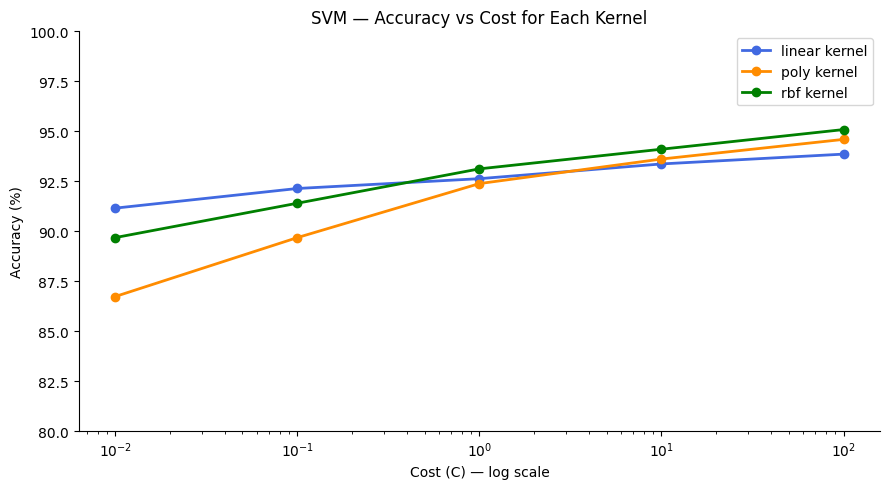

Saved: svm_cost_tuning.png


In [99]:
# Plot cost tuning curves
fig, ax = plt.subplots(figsize=(9, 5))
colors = {'linear': 'royalblue', 'poly': 'darkorange', 'rbf': 'green'}

for kernel in kernels:
    accs = [tuning_results[kernel][C] * 100 for C in costs]
    ax.plot(costs, accs, marker='o', linewidth=2,
            color=colors[kernel], label=f'{kernel} kernel')

ax.set_xscale('log')
ax.set_xlabel('Cost (C) — log scale')
ax.set_ylabel('Accuracy (%)')
ax.set_title('SVM — Accuracy vs Cost for Each Kernel')
ax.legend()
ax.set_ylim(80, 100)
sns.despine()
plt.tight_layout()
plt.savefig('svm_cost_tuning.png', dpi=150)
plt.show()
print('Saved: svm_cost_tuning.png')

In [100]:
# Find best C for each kernel and train final models
best_svms = {}
for kernel in kernels:
    best_C = max(tuning_results[kernel], key=tuning_results[kernel].get)
    svm = SVC(kernel=kernel, C=best_C, degree=3, gamma='scale', random_state=42)
    svm.fit(X_train_svm, y_train)
    y_pred = svm.predict(X_test_svm)
    acc = accuracy_score(y_test, y_pred)
    best_svms[kernel] = {'model': svm, 'C': best_C, 'y_pred': y_pred, 'acc': acc}
    print(f'{kernel:8s} kernel (C={best_C:4}) — Accuracy: {acc*100:.2f}%')
    print(classification_report(y_test, y_pred,
                                target_names=['No Irrigation', 'Needs Irrigation']))
    print()

linear   kernel (C= 100) — Accuracy: 93.86%
                  precision    recall  f1-score   support

   No Irrigation       0.97      0.94      0.95       282
Needs Irrigation       0.87      0.94      0.90       125

        accuracy                           0.94       407
       macro avg       0.92      0.94      0.93       407
    weighted avg       0.94      0.94      0.94       407


poly     kernel (C= 100) — Accuracy: 94.59%
                  precision    recall  f1-score   support

   No Irrigation       0.96      0.96      0.96       282
Needs Irrigation       0.92      0.90      0.91       125

        accuracy                           0.95       407
       macro avg       0.94      0.93      0.94       407
    weighted avg       0.95      0.95      0.95       407


rbf      kernel (C= 100) — Accuracy: 95.09%
                  precision    recall  f1-score   support

   No Irrigation       0.97      0.95      0.96       282
Needs Irrigation       0.90      0.94      0.92

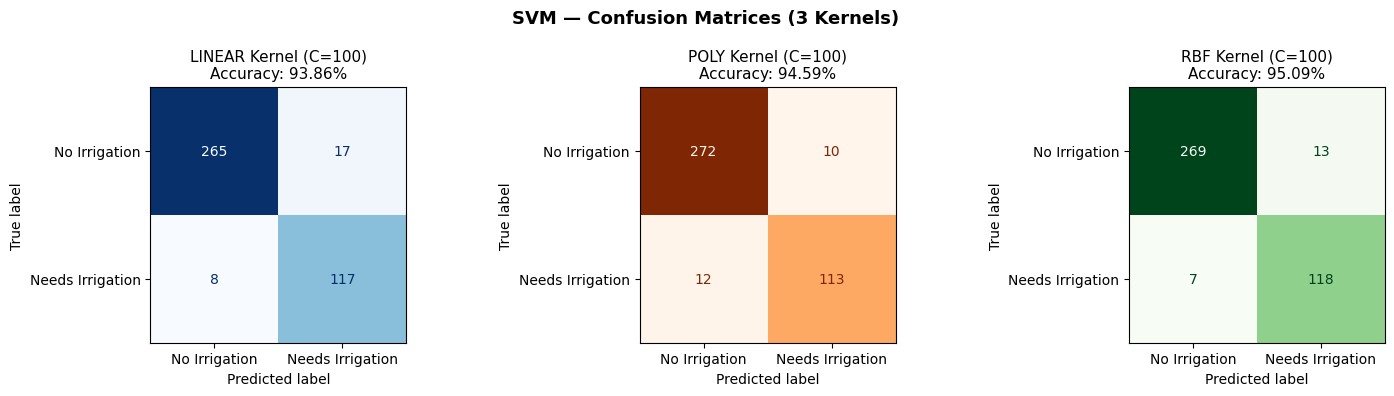

Saved: svm_confusion_matrices.png


In [101]:
# Confusion matrices for all 3 kernels
class_names = ['No Irrigation', 'Needs Irrigation']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kernel_colors = {'linear': 'Blues', 'poly': 'Oranges', 'rbf': 'Greens'}

for ax, kernel in zip(axes, kernels):
    info = best_svms[kernel]
    cm = confusion_matrix(y_test, info['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, colorbar=False, cmap=kernel_colors[kernel]
    )
    ax.set_title(f'{kernel.upper()} Kernel (C={info["C"]})\nAccuracy: {info["acc"]*100:.2f}%',
                 fontsize=11)

plt.suptitle('SVM — Confusion Matrices (3 Kernels)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_confusion_matrices.png', dpi=150)
plt.show()
print('Saved: svm_confusion_matrices.png')

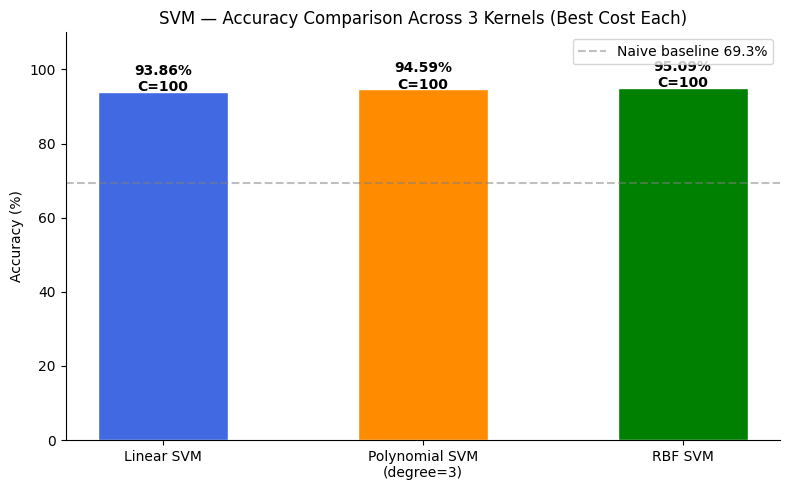

Saved: svm_accuracy_comparison.png


In [102]:
# SVM accuracy comparison bar chart
svm_names = ['Linear SVM', 'Polynomial SVM\n(degree=3)', 'RBF SVM']
svm_accs  = [best_svms[k]['acc'] * 100 for k in kernels]
svm_costs = [best_svms[k]['C'] for k in kernels]
colors_bar = ['royalblue', 'darkorange', 'green']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(svm_names, svm_accs, color=colors_bar, width=0.5, edgecolor='white')
for bar, acc, C in zip(bars, svm_accs, svm_costs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{acc:.2f}%\nC={C}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('SVM — Accuracy Comparison Across 3 Kernels (Best Cost Each)')
ax.axhline(69.3, color='gray', linestyle='--', alpha=0.5, label='Naive baseline 69.3%')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('svm_accuracy_comparison.png', dpi=150)
plt.show()
print('Saved: svm_accuracy_comparison.png')

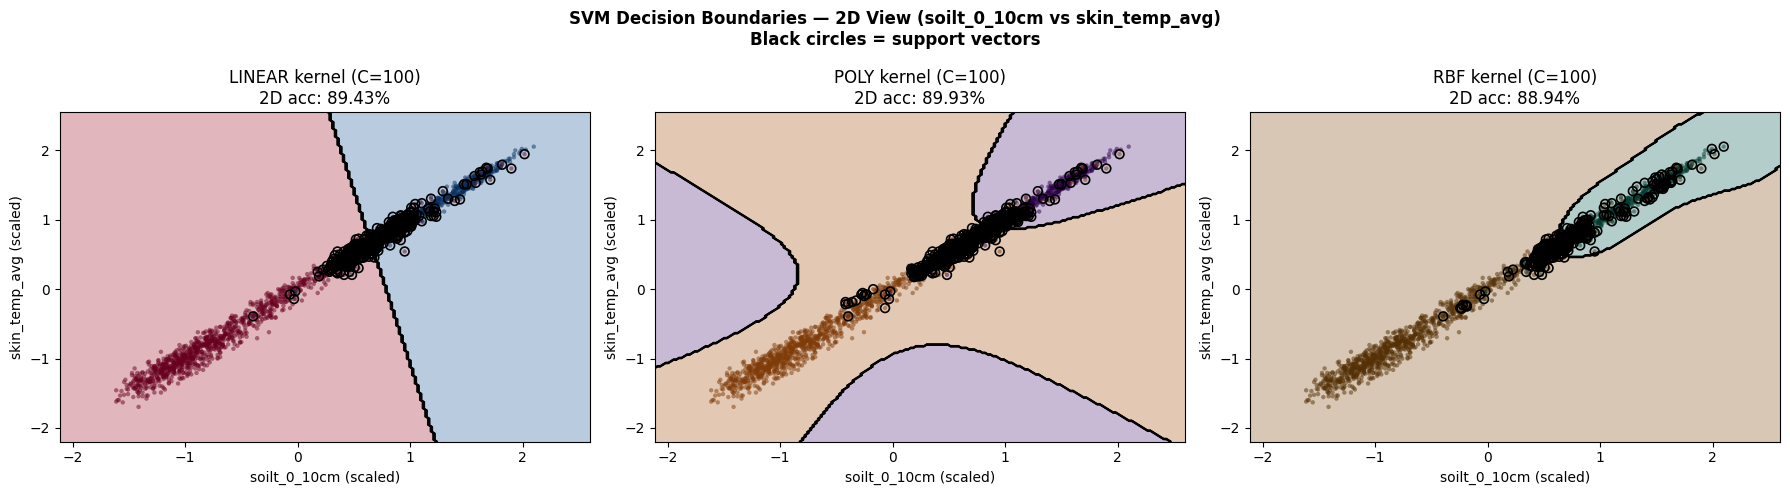

Saved: svm_decision_boundaries.png


In [103]:
# 2D decision boundary plots for each kernel (using top 2 features)
feat_2d = ['soilt_0_10cm', 'skin_temp_avg']
X_2d = df[feat_2d]
y_2d = df['irrigation_needed']

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)
sc2 = StandardScaler()
X_tr2s = sc2.fit_transform(X_tr2)
X_te2s  = sc2.transform(X_te2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
kernel_colors_map = {'linear': 'RdBu', 'poly': 'PuOr', 'rbf': 'BrBG'}

for ax, kernel in zip(axes, kernels):
    best_C = best_svms[kernel]['C']
    svm_2d = SVC(kernel=kernel, C=best_C, degree=3, gamma='scale')
    svm_2d.fit(X_tr2s, y_tr2)
    acc_2d = accuracy_score(y_te2, svm_2d.predict(X_te2s))

    xx, yy = np.meshgrid(
        np.linspace(X_tr2s[:,0].min()-0.5, X_tr2s[:,0].max()+0.5, 200),
        np.linspace(X_tr2s[:,1].min()-0.5, X_tr2s[:,1].max()+0.5, 200)
    )
    Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=kernel_colors_map[kernel])
    ax.contour(xx, yy, Z, colors='black', linewidths=0.8)
    ax.scatter(X_tr2s[:,0], X_tr2s[:,1], c=y_tr2,
               cmap=kernel_colors_map[kernel], s=10, alpha=0.5, edgecolors='none')
    sv = svm_2d.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=40, facecolors='none',
               edgecolors='black', linewidths=1.2)
    ax.set_title(f'{kernel.upper()} kernel (C={best_C})\n2D acc: {acc_2d*100:.2f}%')
    ax.set_xlabel('soilt_0_10cm (scaled)')
    ax.set_ylabel('skin_temp_avg (scaled)')

plt.suptitle('SVM Decision Boundaries — 2D View (soilt_0_10cm vs skin_temp_avg)\nBlack circles = support vectors',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_decision_boundaries.png', dpi=150)
plt.show()
print('Saved: svm_decision_boundaries.png')

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

# SVM
from sklearn.svm import SVC

# Ensemble
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    BaggingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

print('All imports successful')

All imports successful


In [106]:
# Method 1: Random Forest — bagging with many decision trees
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf  = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy    : {acc_rf*100:.2f}%')
print(classification_report(y_test, y_pred_rf,
                             target_names=['No Irrigation', 'Needs Irrigation']))

Random Forest Accuracy    : 93.61%
                  precision    recall  f1-score   support

   No Irrigation       0.96      0.95      0.95       282
Needs Irrigation       0.88      0.91      0.90       125

        accuracy                           0.94       407
       macro avg       0.92      0.93      0.93       407
    weighted avg       0.94      0.94      0.94       407



In [107]:
# Method 2: Gradient Boosting — sequential boosting (each tree corrects previous errors)
gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1,
    max_depth=4, random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb  = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f'Gradient Boosting Accuracy: {acc_gb*100:.2f}%')
print(classification_report(y_test, y_pred_gb,
                             target_names=['No Irrigation', 'Needs Irrigation']))

Gradient Boosting Accuracy: 94.10%
                  precision    recall  f1-score   support

   No Irrigation       0.96      0.95      0.96       282
Needs Irrigation       0.89      0.92      0.91       125

        accuracy                           0.94       407
       macro avg       0.93      0.94      0.93       407
    weighted avg       0.94      0.94      0.94       407



In [108]:
# Method 3: Voting Classifier — combines DT + LR + RF by majority vote
dt_base = DecisionTreeClassifier(max_depth=5, random_state=42)
lr_base = LogisticRegression(max_iter=1000, random_state=42)
rf_base = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

voting = VotingClassifier(
    estimators=[('dt', dt_base), ('lr', lr_base), ('rf', rf_base)],
    voting='hard'
)
voting.fit(X_train, y_train)
y_pred_vote = voting.predict(X_test)
acc_vote = accuracy_score(y_test, y_pred_vote)
print(f'Voting Classifier Accuracy: {acc_vote*100:.2f}%')
print(classification_report(y_test, y_pred_vote,
                             target_names=['No Irrigation', 'Needs Irrigation']))

Voting Classifier Accuracy: 93.37%
                  precision    recall  f1-score   support

   No Irrigation       0.96      0.95      0.95       282
Needs Irrigation       0.88      0.90      0.89       125

        accuracy                           0.93       407
       macro avg       0.92      0.93      0.92       407
    weighted avg       0.93      0.93      0.93       407



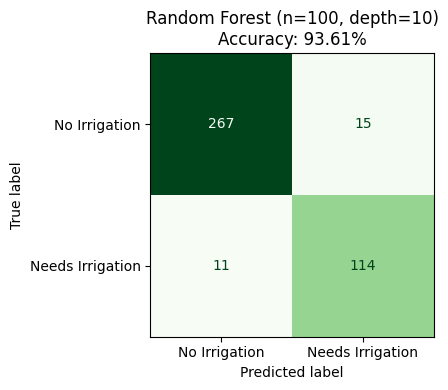

Saved: rf_confusion_matrix.png


In [157]:
fig, ax = plt.subplots(figsize=(5, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=class_names).plot(
    ax=ax, colorbar=False, cmap='Greens'
)
ax.set_title(f'Random Forest (n=100, depth=10)\nAccuracy: {acc_rf*100:.2f}%', fontsize=12)
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()
print("Saved: rf_confusion_matrix.png")

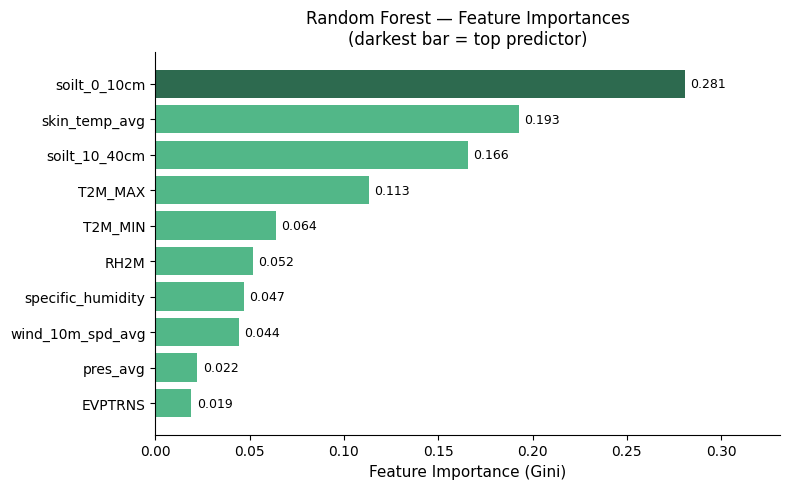

Saved: rf_feature_importance.png


In [158]:
importance_df = pd.DataFrame({
    'Feature':    features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2D6A4F' if imp == importance_df['Importance'].max()
          else '#52B788' for imp in importance_df['Importance']]
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors)

# Label each bar
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Random Forest — Feature Importances\n(darkest bar = top predictor)', fontsize=12)
ax.set_xlim(0, importance_df['Importance'].max() * 1.18)
sns.despine()
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()
print("Saved: rf_feature_importance.png")

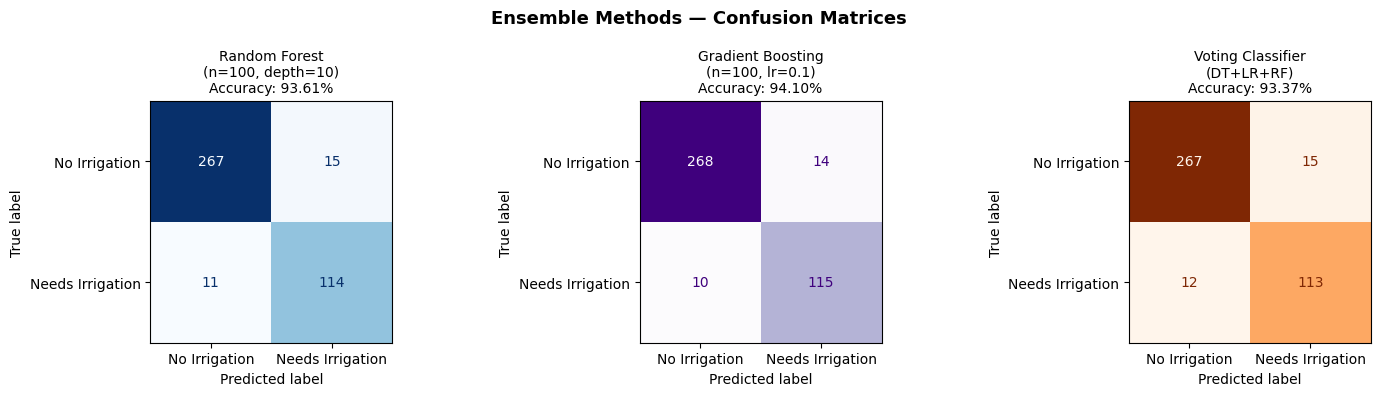

Saved: ensemble_confusion_matrices.png


In [109]:
# Ensemble confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ensemble_models = [
    ('Random Forest\n(n=100, depth=10)', y_pred_rf,   acc_rf,   'Blues'),
    ('Gradient Boosting\n(n=100, lr=0.1)', y_pred_gb, acc_gb,   'Purples'),
    ('Voting Classifier\n(DT+LR+RF)',     y_pred_vote, acc_vote, 'Oranges'),
]

for ax, (name, preds, acc, cmap) in zip(axes, ensemble_models):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['No Irrigation','Needs Irrigation']).plot(
        ax=ax, colorbar=False, cmap=cmap
    )
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontsize=10)

plt.suptitle('Ensemble Methods — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ensemble_confusion_matrices.png', dpi=150)
plt.show()
print('Saved: ensemble_confusion_matrices.png')

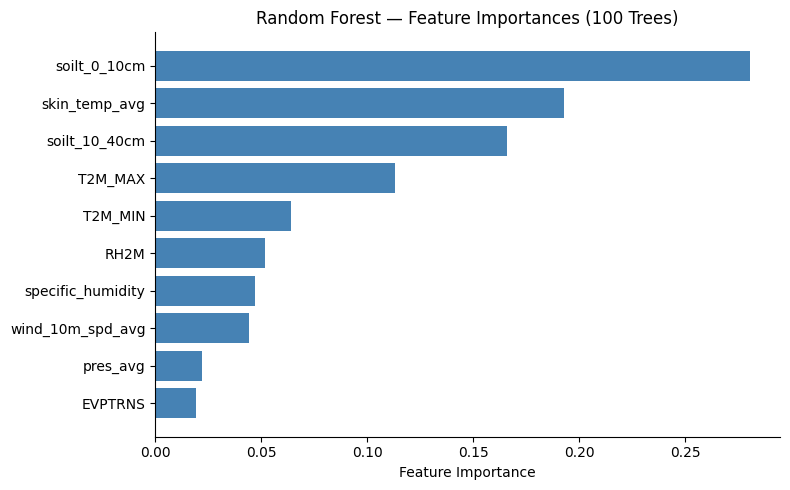

Saved: ensemble_rf_importance.png


In [110]:
# Random Forest feature importance
rf_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(rf_importance['Feature'], rf_importance['Importance'], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest — Feature Importances (100 Trees)')
sns.despine()
plt.tight_layout()
plt.savefig('ensemble_rf_importance.png', dpi=150)
plt.show()
print('Saved: ensemble_rf_importance.png')

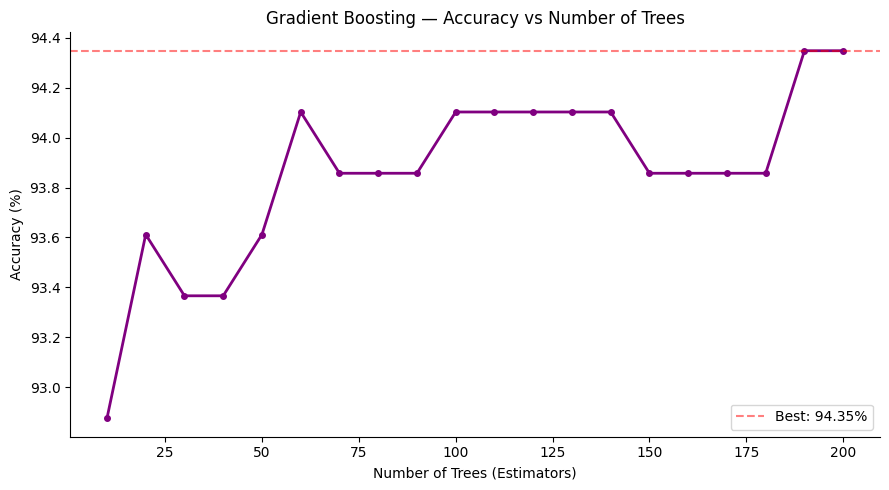

Saved: ensemble_gb_learning_curve.png


In [111]:
# Gradient Boosting — learning curve (accuracy vs number of trees)
n_trees_range = range(10, 201, 10)
gb_staged_accs = []

for n in n_trees_range:
    gb_temp = GradientBoostingClassifier(
        n_estimators=n, learning_rate=0.1, max_depth=4, random_state=42
    )
    gb_temp.fit(X_train, y_train)
    gb_staged_accs.append(accuracy_score(y_test, gb_temp.predict(X_test)) * 100)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(n_trees_range), gb_staged_accs, color='purple', linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Number of Trees (Estimators)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Gradient Boosting — Accuracy vs Number of Trees')
ax.axhline(max(gb_staged_accs), color='red', linestyle='--', alpha=0.5,
           label=f'Best: {max(gb_staged_accs):.2f}%')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('ensemble_gb_learning_curve.png', dpi=150)
plt.show()
print('Saved: ensemble_gb_learning_curve.png')

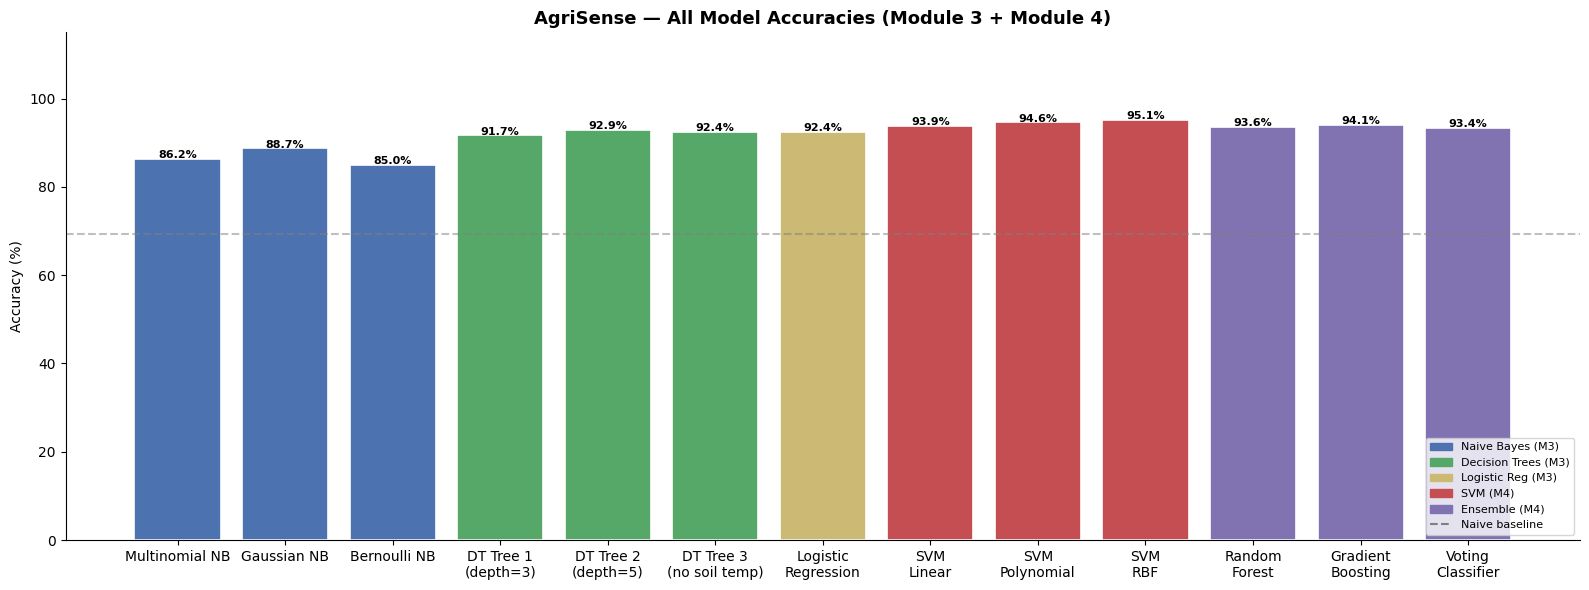

Saved: all_models_accuracy_final.png


In [112]:
# Reload Module 3 results if needed (or hardcode from earlier)
# These match confirmed Module 3 accuracies
module3_names = [
    'Multinomial NB', 'Gaussian NB', 'Bernoulli NB',
    'DT Tree 1\n(depth=3)', 'DT Tree 2\n(depth=5)', 'DT Tree 3\n(no soil temp)',
    'Logistic\nRegression'
]
module3_accs = [86.24, 88.70, 85.01, 91.65, 92.87, 92.38, 92.38]

module4_names = [
    'SVM\nLinear', 'SVM\nPolynomial', 'SVM\nRBF',
    'Random\nForest', 'Gradient\nBoosting', 'Voting\nClassifier'
]
module4_accs = [
    best_svms['linear']['acc']*100,
    best_svms['poly']['acc']*100,
    best_svms['rbf']['acc']*100,
    acc_rf*100, acc_gb*100, acc_vote*100
]

all_names = module3_names + module4_names
all_accs  = module3_accs  + module4_accs
all_colors = (['#4C72B0']*3 + ['#55A868']*3 + ['#CCB974'] +
              ['#C44E52']*3 + ['#8172B2']*3)

fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(all_names, all_accs, color=all_colors, edgecolor='white', linewidth=1.2)

for bar, acc in zip(bars, all_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{acc:.1f}%', ha='center', fontsize=8, fontweight='bold')

ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)')
ax.set_title('AgriSense — All Model Accuracies (Module 3 + Module 4)',
             fontsize=13, fontweight='bold')
ax.axhline(69.3, color='gray', linestyle='--', alpha=0.5, label='Naive baseline 69.3%')

# Legend for module groups
import matplotlib.patches as mpatches
legend_items = [
    mpatches.Patch(color='#4C72B0', label='Naive Bayes (M3)'),
    mpatches.Patch(color='#55A868', label='Decision Trees (M3)'),
    mpatches.Patch(color='#CCB974', label='Logistic Reg (M3)'),
    mpatches.Patch(color='#C44E52', label='SVM (M4)'),
    mpatches.Patch(color='#8172B2', label='Ensemble (M4)'),
    plt.Line2D([0],[0], color='gray', linestyle='--', label='Naive baseline'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig('all_models_accuracy_final.png', dpi=150)
plt.show()
print('Saved: all_models_accuracy_final.png')